In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from pytorch_msssim import ms_ssim

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.ndimage import zoom
from sklearn.model_selection import KFold

In [3]:
DEUTERONS = '/Users/user/data/research/proton-deuteron/csv/deuteron_candidates_induction.pkl'   # DEUTERON CANDIDATES CLUSTERS - INDUCTION PLANE
PROTONS = '/Users/user/data/research/proton-deuteron/csv/proton_candidates_induction.pkl'       # PROTON CANDIDATES CLUSTERS - INDUCTION PLANE

masses = pd.read_csv('/Users/user/data/research/proton-deuteron/csv/picky+match.csv')           # BEAMLINE INFO. 

deuterons = pd.read_pickle(DEUTERONS); 
protons = pd.read_pickle(PROTONS)

deuterons = pd.merge(
    deuterons,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

protons = pd.merge(
    protons,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

data = pd.concat([deuterons, protons], ignore_index=True)

In [4]:
protons.shape, deuterons.shape

((7448, 37), (6963, 37))

In [5]:
protons = protons[(protons['height'] < 100) & (protons['width'] < 400)]
deuterons = deuterons[(deuterons['height'] < 100) & (deuterons['width'] < 400)]

In [6]:
protons.shape, deuterons.shape

((6291, 37), (5115, 37))

In [7]:
max(deuterons['width']), max(deuterons['height']), max(protons['width']), max(protons['height'])

(399, 99, 399, 99)

In [8]:
def pad_image(image, target_wh=(1024, 99)):
    """
    Place a 2D image block in the centre of a zero canvas.

    image: 2D np.ndarray, shape (h, w)
    target_wh: (target_width, target_height)
    """
    target_w, target_h = target_wh
    canvas = np.zeros((target_h, target_w), dtype=image.dtype)

    h, w = image.shape
    
    v = int(np.argmax(image[0]))

    a = 512 - v
    
    # Compute top-left corner so image is centred
    y0 = 0
    x0 = a
    y1 = y0 + h
    x1 = x0 + w

    # Place the image block
    canvas[y0:y1, x0:x1] = image

    return canvas

<Axes: >

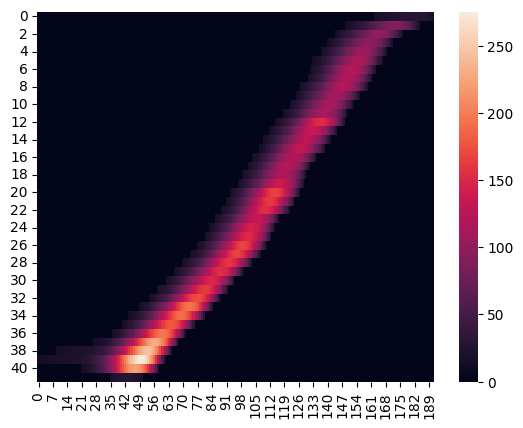

In [9]:
i = 14
sns.heatmap(protons['image_intensity'].iloc[i])

In [10]:
int(np.argmax(protons['image_intensity'].iloc[i][0]))

180

In [11]:
pv = []                                                 # vertex
pe = []                                                 # end   
for idx, row in protons.iterrows():
    vertex = np.argmax(row['image_intensity'][0])
    end = np.argmax(row['image_intensity'][-1])
    pv.append(vertex)
    pe.append(end)

pv = np.array(pv)
pe = np.array(pe)

dv = []                                                 # vertex
de = []                                                 # end   
for idx, row in deuterons.iterrows():
    vertex = np.argmax(row['image_intensity'][0])
    end = np.argmax(row['image_intensity'][-1])
    dv.append(vertex)
    de.append(end)

np.int64(-348)

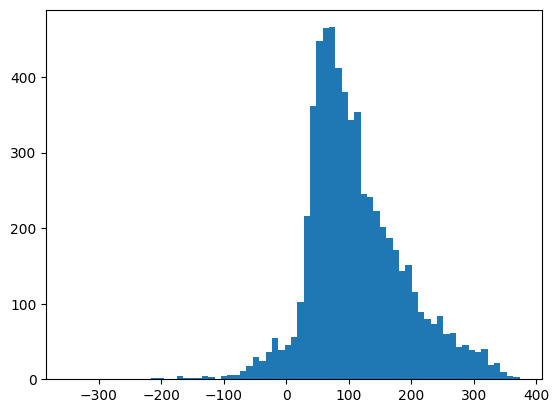

In [12]:
plt.hist(pv - pe, bins='auto')
min(pv-pe)

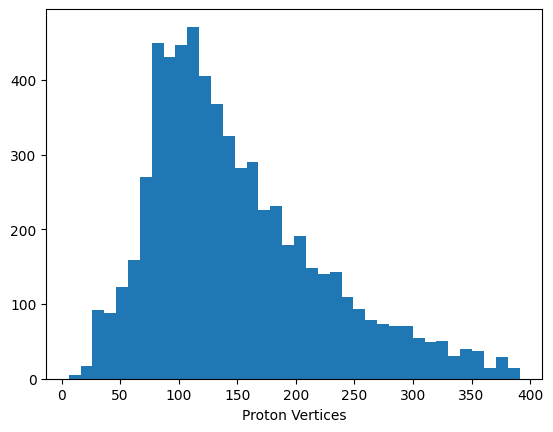

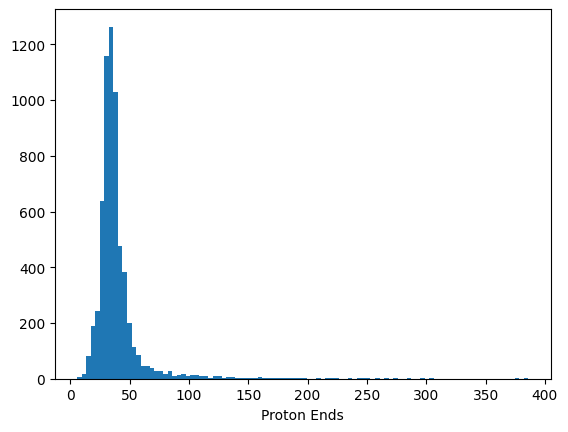

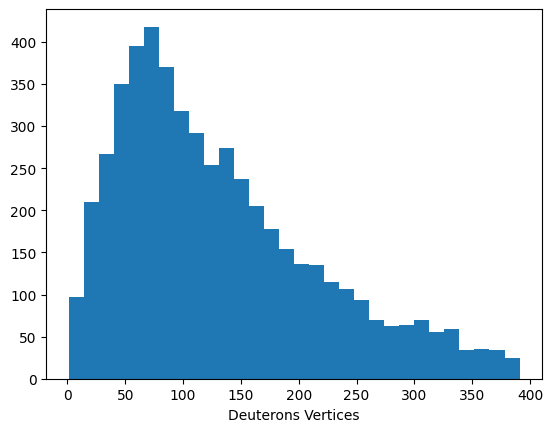

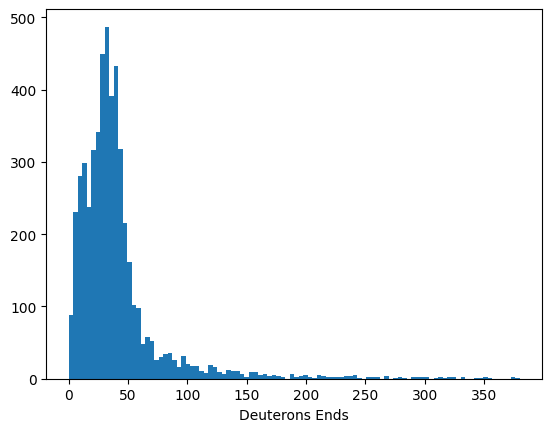

In [13]:
plt.hist(pv, bins='auto'); plt.xlabel('Proton Vertices'); plt.show()
plt.hist(pe, bins=100); plt.xlabel('Proton Ends'); plt.show()
plt.hist(dv, bins='auto'); plt.xlabel('Deuterons Vertices'); plt.show()
plt.hist(de, bins=100); plt.xlabel('Deuterons Ends'); plt.show()

<Axes: >

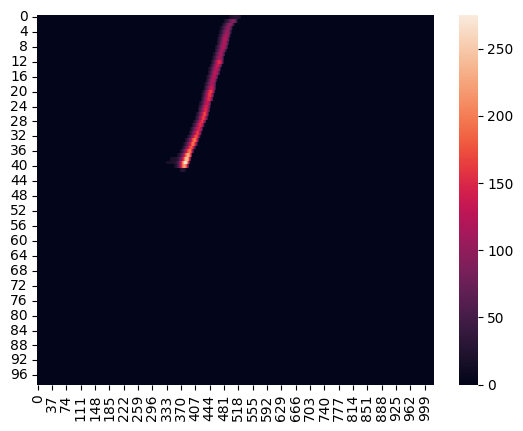

In [14]:
pad = pad_image(protons['image_intensity'].iloc[i])
sns.heatmap(pad)

In [15]:
def downsample_image(image, target_shape=(512, 40)):
    scale_y = target_shape[1] / image.shape[0]
    scale_x = target_shape[0] / image.shape[1]
    return zoom(image, (scale_y, scale_x), order=1)  # order=1 for bilinear interpolation

In [16]:
p = [] 
d = []

for idx, row in protons.iterrows():
    padded = pad_image(
        row['image_intensity'])
    p.append(padded)

for idx, row in deuterons.iterrows():
    padded = pad_image(
        row['image_intensity'])
    d.append(padded)

p = np.array(p)
d = np.array(d)

p_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in p])
d_d = np.array([downsample_image(img, target_shape=(64, 64)) for img in d])

In [17]:
imgpv = []                                                 # vertex
imgpe = []                                                 # end   
for img in p_d:
    vertex = np.argmax(img[0])
    end = np.argmax(img[-1])
    imgpv.append(vertex)
    imgpe.append(end)

imgdv = []                                                 # vertex
imgde = []                                                 # end   
for img in d_d:
    vertex = np.argmax(img[0])
    end = np.argmax(img[-1])
    imgdv.append(vertex)
    imgde.append(end)

0


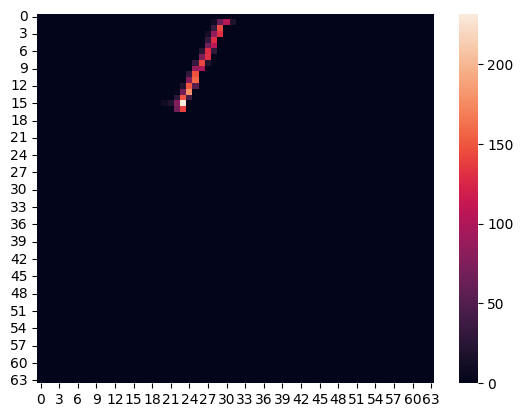

In [18]:
i = 2
sns.heatmap(p_d[i]); print(np.argmax(p_d[i][0]))

<Axes: >

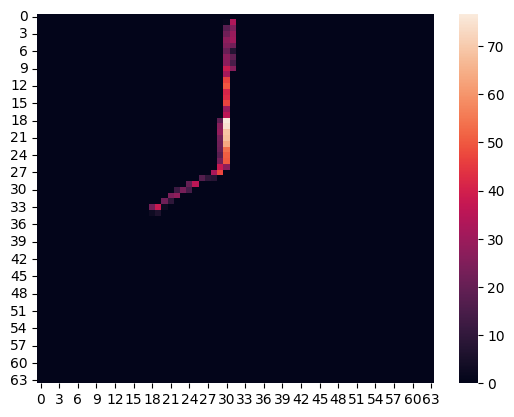

In [19]:
sns.heatmap(d_d[3])

In [20]:
class CAE(nn.Module):
    def __init__(self, input_hw=(240, 240), latent=8):
        super(CAE, self).__init__()
        in_h, in_w = input_hw
        assert in_h % 16 == 0 and in_w % 16 == 0, "input spatial dims must be divisible by 16"

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 5, stride=2, padding=2), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 5, stride=2, padding=2), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 5, stride=2, padding=2), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 5, stride=2, padding=2), nn.BatchNorm2d(256), nn.ReLU()
        )

        self.h_enc = in_h // 16
        self.w_enc = in_w // 16
        flat_size = 256 * self.h_enc * self.w_enc

        self.fc_enc = nn.Linear(flat_size, latent)
        self.fc_dec = nn.Linear(latent, flat_size)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 5, stride=2, padding=2, output_padding=1),
            nn.ReLU()  
        )

    def forward(self, x):
        x = x.unsqueeze(1)               # (B,1,H,W)
        enc = self.encoder(x)            # (B,256,H_enc,W_enc)
        z = enc.view(enc.size(0), -1)    # (B, flat_size)
        z = self.fc_enc(z)               # (B, latent)
        z = self.fc_dec(z)               # (B, flat_size)
        y = z.view(x.size(0), 256, self.h_enc, self.w_enc)  # (B,256,H_enc,W_enc)
        y = self.decoder(y).squeeze(1)   # (B,H,W)
        return y

In [21]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Training device:", device)

X = torch.tensor(p_d, dtype=torch.float32)  # shape (N, H, W)
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

epochs = 50
batch_size = 32

fold_train_losses, fold_val_losses = [], []
fold_REs = []
fold_REs_d_d = []

Training device: mps



===== Fold 1/5 =====
Epoch 1/50: Train=56.5769, Val=33.2092
Epoch 2/50: Train=25.9164, Val=22.1475
Epoch 3/50: Train=19.3178, Val=16.8814
Epoch 4/50: Train=15.6758, Val=15.5148
Epoch 5/50: Train=13.9157, Val=13.4826
Epoch 6/50: Train=12.1000, Val=12.2165
Epoch 7/50: Train=10.8915, Val=11.7122
Epoch 8/50: Train=10.5339, Val=10.0600
Epoch 9/50: Train=9.2858, Val=10.9269
Epoch 10/50: Train=9.0705, Val=10.0012
Epoch 11/50: Train=8.1370, Val=9.3277
Epoch 12/50: Train=7.8321, Val=9.0950
Epoch 13/50: Train=7.3856, Val=8.6479
Epoch 14/50: Train=7.0723, Val=8.5433
Epoch 15/50: Train=7.0404, Val=7.8754
Epoch 16/50: Train=6.6522, Val=8.2252
Epoch 17/50: Train=6.4054, Val=7.6454
Epoch 18/50: Train=5.9167, Val=7.7834
Epoch 19/50: Train=6.1684, Val=7.3524
Epoch 20/50: Train=5.6920, Val=7.7667
Epoch 21/50: Train=5.7813, Val=7.3793
Epoch 22/50: Train=5.4744, Val=7.4479
Epoch 23/50: Train=5.4484, Val=6.9941
Epoch 24/50: Train=5.4126, Val=7.2498
Epoch 25/50: Train=5.4241, Val=7.1354
Epoch 26/50: Train=

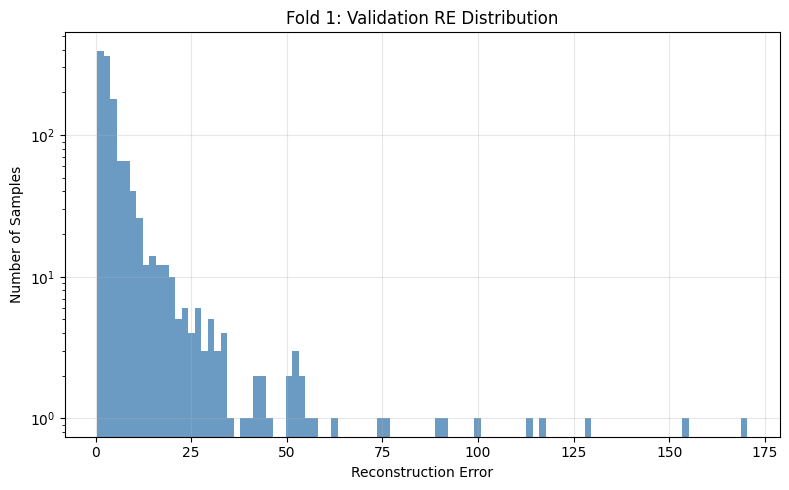

Computing RE on unseen dataset (d_d)...


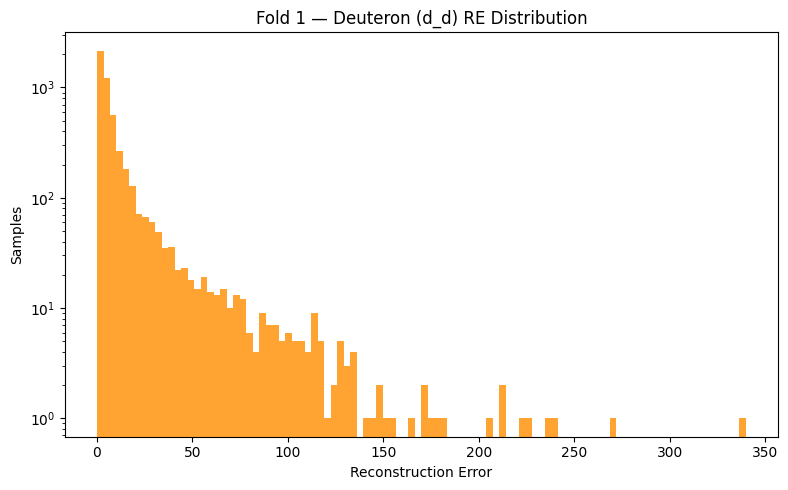


===== Fold 2/5 =====
Epoch 1/50: Train=60.3272, Val=36.0355
Epoch 2/50: Train=29.2180, Val=22.4726
Epoch 3/50: Train=21.3658, Val=17.7659
Epoch 4/50: Train=17.5058, Val=17.0946
Epoch 5/50: Train=15.5037, Val=15.2878
Epoch 6/50: Train=14.0119, Val=13.2559
Epoch 7/50: Train=11.9525, Val=11.7584
Epoch 8/50: Train=11.0430, Val=11.4585
Epoch 9/50: Train=10.1776, Val=10.3438
Epoch 10/50: Train=9.6183, Val=9.8498
Epoch 11/50: Train=9.0828, Val=8.7367
Epoch 12/50: Train=8.2460, Val=9.6562
Epoch 13/50: Train=8.0852, Val=8.7868
Epoch 14/50: Train=7.9129, Val=9.1131
Epoch 15/50: Train=7.4682, Val=8.4317
Epoch 16/50: Train=6.9753, Val=8.4405
Epoch 17/50: Train=6.8335, Val=7.4352
Epoch 18/50: Train=6.6027, Val=7.9242
Epoch 19/50: Train=6.3174, Val=7.2392
Epoch 20/50: Train=5.9464, Val=8.1039
Epoch 21/50: Train=6.0202, Val=7.7961
Epoch 22/50: Train=6.0132, Val=6.9637
Epoch 23/50: Train=5.7007, Val=7.3751
Epoch 24/50: Train=5.6508, Val=7.6663
Epoch 25/50: Train=5.6614, Val=6.9818
Epoch 26/50: Train=

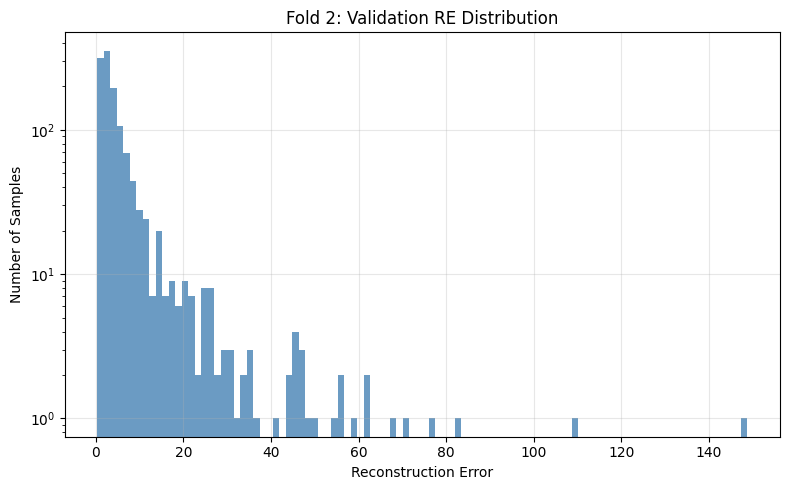

Computing RE on unseen dataset (d_d)...


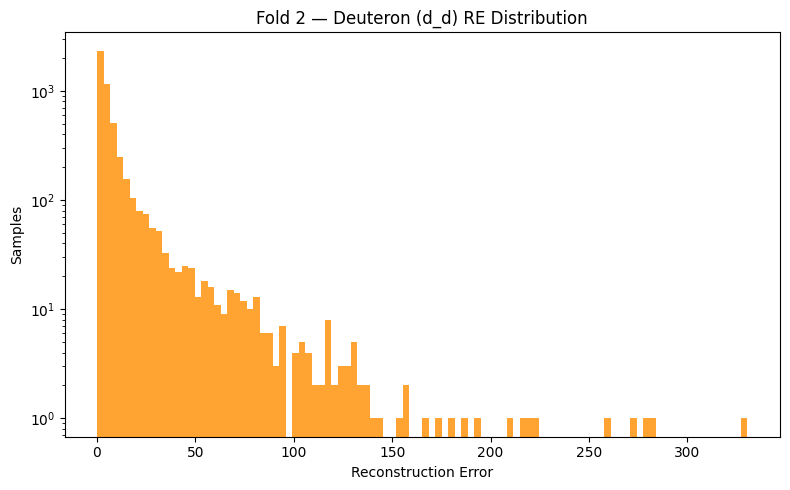


===== Fold 3/5 =====
Epoch 1/50: Train=55.6496, Val=34.8661
Epoch 2/50: Train=27.1028, Val=22.7557
Epoch 3/50: Train=19.1470, Val=17.1415
Epoch 4/50: Train=16.1357, Val=15.0908
Epoch 5/50: Train=13.6828, Val=12.8454
Epoch 6/50: Train=12.6815, Val=12.4457
Epoch 7/50: Train=11.5744, Val=11.5754
Epoch 8/50: Train=10.0880, Val=10.3583
Epoch 9/50: Train=9.6328, Val=9.9952
Epoch 10/50: Train=8.7821, Val=10.3816
Epoch 11/50: Train=8.9889, Val=9.6983
Epoch 12/50: Train=8.1890, Val=9.5571
Epoch 13/50: Train=7.5063, Val=8.8584
Epoch 14/50: Train=7.4663, Val=8.4898
Epoch 15/50: Train=7.2346, Val=8.0646
Epoch 16/50: Train=6.7930, Val=8.4872
Epoch 17/50: Train=6.3800, Val=7.7761
Epoch 18/50: Train=6.6242, Val=8.5345
Epoch 19/50: Train=6.2611, Val=7.2339
Epoch 20/50: Train=5.8175, Val=7.6824
Epoch 21/50: Train=6.0812, Val=7.3742
Epoch 22/50: Train=5.6406, Val=6.9058
Epoch 23/50: Train=5.8949, Val=7.8142
Epoch 24/50: Train=5.4249, Val=7.4069
Epoch 25/50: Train=5.1679, Val=6.5658
Epoch 26/50: Train=4

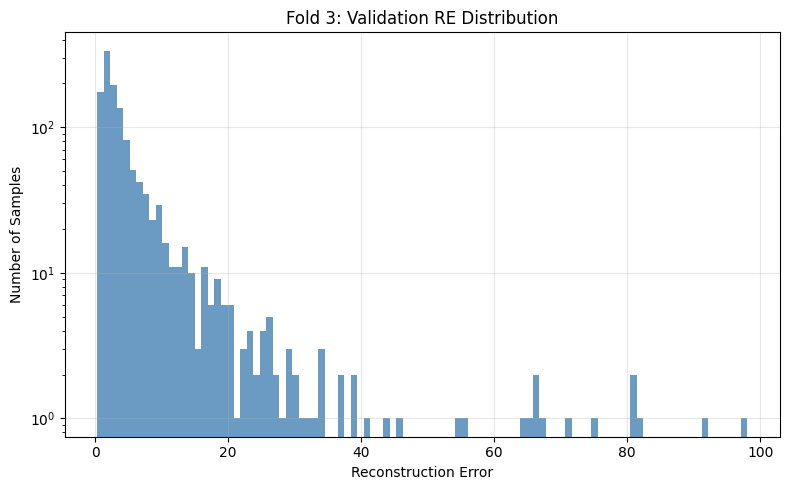

Computing RE on unseen dataset (d_d)...


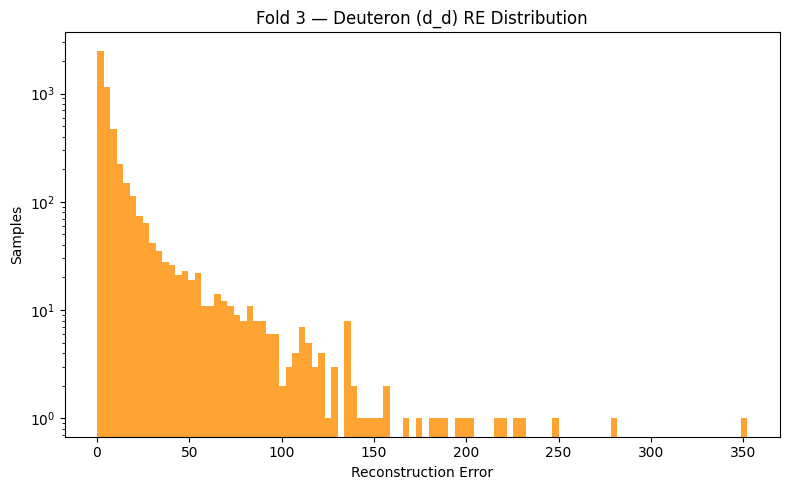


===== Fold 4/5 =====
Epoch 1/50: Train=58.3120, Val=33.3924
Epoch 2/50: Train=27.1317, Val=22.4179
Epoch 3/50: Train=19.8580, Val=20.1636
Epoch 4/50: Train=16.1031, Val=15.5407
Epoch 5/50: Train=14.3235, Val=14.0245
Epoch 6/50: Train=13.0327, Val=12.4246
Epoch 7/50: Train=11.5651, Val=11.9200
Epoch 8/50: Train=10.3897, Val=11.0191
Epoch 9/50: Train=9.9132, Val=11.2318
Epoch 10/50: Train=9.2492, Val=9.5750
Epoch 11/50: Train=8.7534, Val=9.9361
Epoch 12/50: Train=8.2551, Val=9.4306
Epoch 13/50: Train=7.9344, Val=8.8461
Epoch 14/50: Train=7.5468, Val=8.1785
Epoch 15/50: Train=7.1566, Val=8.0232
Epoch 16/50: Train=7.0919, Val=7.9468
Epoch 17/50: Train=6.5777, Val=8.0712
Epoch 18/50: Train=6.2602, Val=7.5494
Epoch 19/50: Train=6.3444, Val=7.6224
Epoch 20/50: Train=6.1637, Val=7.3511
Epoch 21/50: Train=5.9276, Val=7.3921
Epoch 22/50: Train=5.8278, Val=7.6255
Epoch 23/50: Train=5.5731, Val=7.1561
Epoch 24/50: Train=5.4303, Val=7.4991
Epoch 25/50: Train=5.3765, Val=7.0097
Epoch 26/50: Train=5

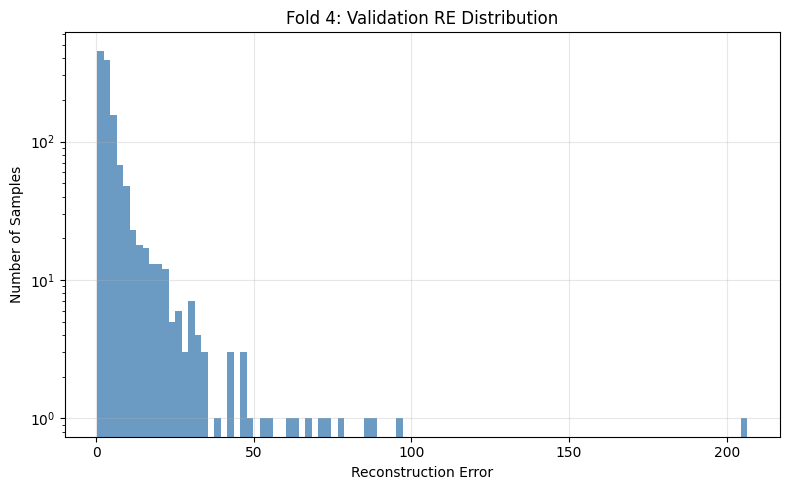

Computing RE on unseen dataset (d_d)...


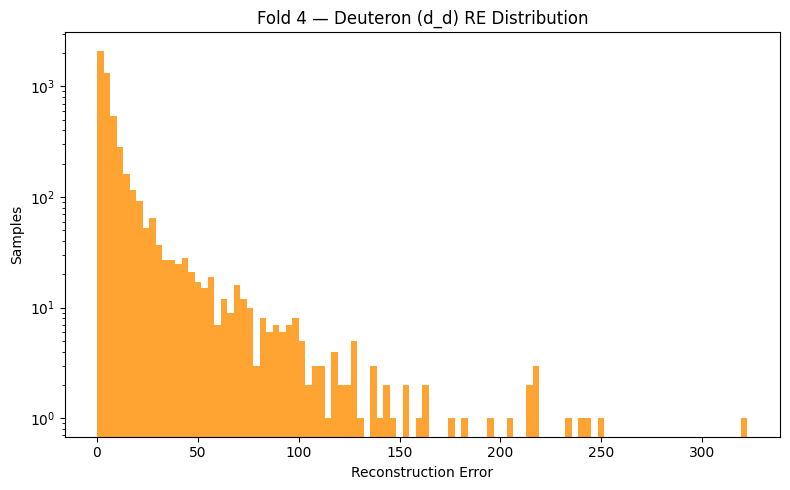


===== Fold 5/5 =====
Epoch 1/50: Train=58.8443, Val=32.7688
Epoch 2/50: Train=28.0666, Val=23.2698
Epoch 3/50: Train=20.3128, Val=18.8479
Epoch 4/50: Train=16.8809, Val=18.3561
Epoch 5/50: Train=15.1053, Val=13.4550
Epoch 6/50: Train=12.6136, Val=12.4625
Epoch 7/50: Train=11.7527, Val=11.1210
Epoch 8/50: Train=10.8466, Val=10.7367
Epoch 9/50: Train=10.1622, Val=9.9591
Epoch 10/50: Train=8.9902, Val=9.3989
Epoch 11/50: Train=8.8627, Val=9.0357
Epoch 12/50: Train=8.4631, Val=8.6792
Epoch 13/50: Train=7.9983, Val=9.1177
Epoch 14/50: Train=7.6775, Val=8.6785
Epoch 15/50: Train=7.6052, Val=8.1738
Epoch 16/50: Train=6.9238, Val=7.5486
Epoch 17/50: Train=6.6956, Val=7.3667
Epoch 18/50: Train=6.5664, Val=7.7884
Epoch 19/50: Train=6.3154, Val=7.0553
Epoch 20/50: Train=5.8298, Val=7.1879
Epoch 21/50: Train=5.7225, Val=6.9923
Epoch 22/50: Train=5.6975, Val=7.3472
Epoch 23/50: Train=5.7601, Val=7.1500
Epoch 24/50: Train=5.4737, Val=6.6814
Epoch 25/50: Train=5.2249, Val=6.6387
Epoch 26/50: Train=5

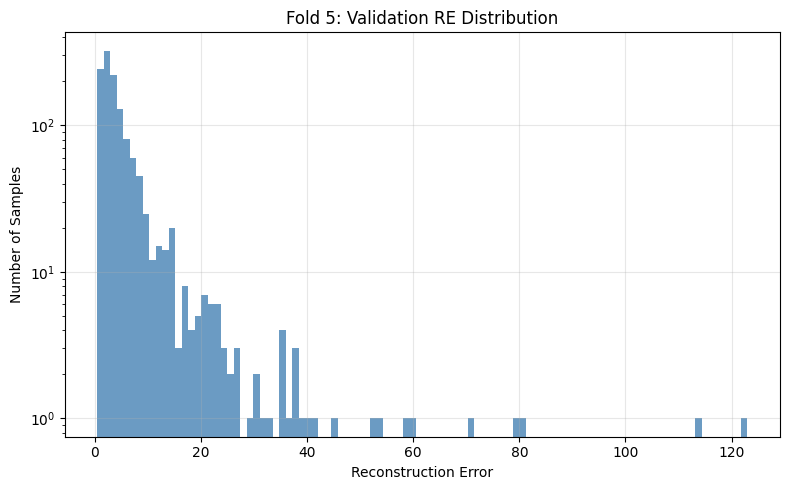

Computing RE on unseen dataset (d_d)...


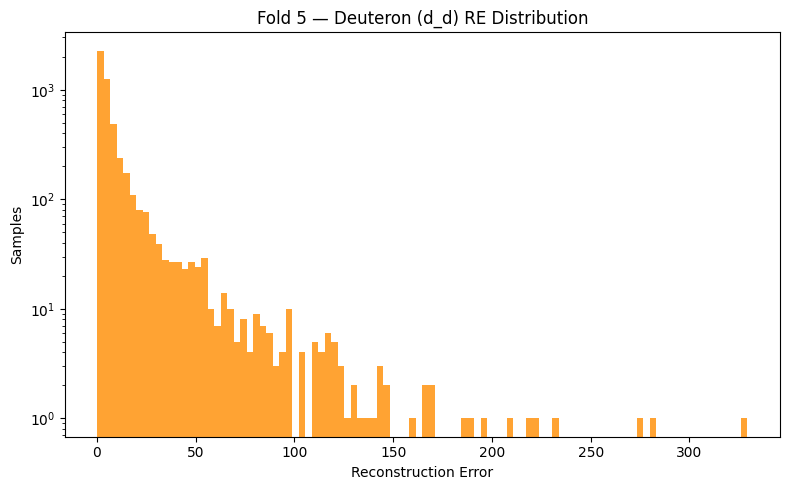

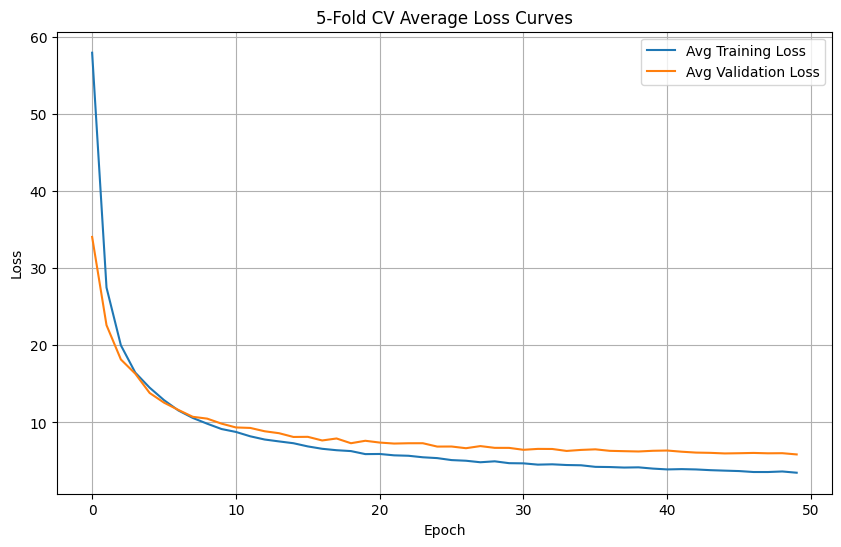

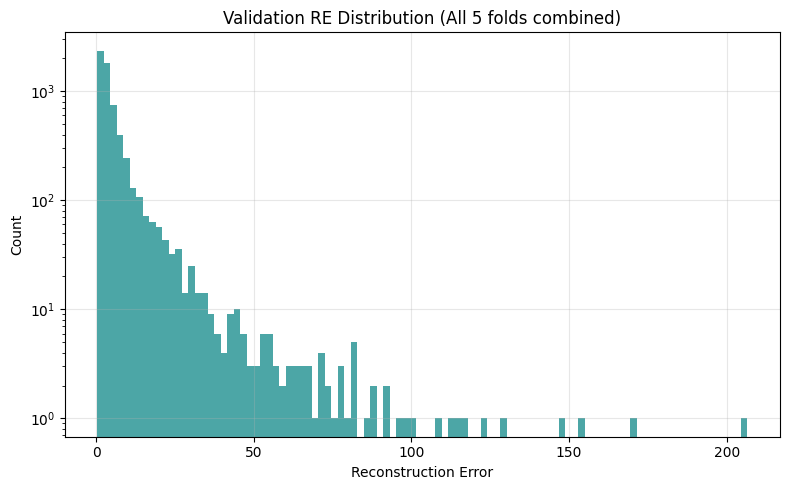

In [22]:
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n===== Fold {fold+1}/{n_splits} =====")

    train_subset = Subset(X, train_idx)
    val_subset = Subset(X, val_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

    model = CAE(input_hw=(64, 64), latent=16).to(device)
    optim = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    train_losses, val_losses = [], []

    # --- Training ---
    for epoch in range(epochs):
        model.train()
        total_train, total_val = 0.0, 0.0

        for xb in train_loader:
            xb = xb.to(device)
            optim.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, xb)
            loss.backward()
            optim.step()
            total_train += loss.item()

        model.eval()
        with torch.no_grad():
            for xb in val_loader:
                xb = xb.to(device)
                preds = model(xb)
                loss = loss_fn(preds, xb)
                total_val += loss.item()

        train_losses.append(total_train / len(train_loader))
        val_losses.append(total_val / len(val_loader))

        print(f"Epoch {epoch+1}/{epochs}: "
              f"Train={train_losses[-1]:.4f}, Val={val_losses[-1]:.4f}")

    fold_train_losses.append(train_losses)
    fold_val_losses.append(val_losses)

    # -----------------------------
    # 4. Reconstruction error (RE) on this fold's validation set
    # -----------------------------
    print("Computing validation REs...")

    model.eval()
    device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    model.to(device_inf)

    X_val_np = torch.stack([val_subset[i] for i in range(len(val_subset))]).cpu().numpy()
    N, H, W = X_val_np.shape
    recon_all = np.empty((N, H, W), dtype=np.float32)

    latent_dim = model.fc_enc.out_features
    latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

    with torch.no_grad():
        for i in range(0, N, 8):
            j = min(i + 8, N)
            xb = torch.tensor(X_val_np[i:j], dtype=torch.float32).to(device_inf)
            out = model(xb)
            recon_all[i:j] = out.cpu().numpy()

            enc = model.encoder(xb.unsqueeze(1))
            z_flat = enc.flatten(1)
            z = model.fc_enc(z_flat)
            latent_vectors[i:j] = z.cpu().numpy()

            if device_inf.type == "mps":
                try:
                    torch.mps.empty_cache()
                except Exception:
                    pass

    mse_per_pixel = (recon_all - X_val_np) ** 2
    RE_per_sample = mse_per_pixel.mean(axis=(1, 2))
    fold_REs.append(RE_per_sample)

    plt.figure(figsize=(8, 5))
    plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Number of Samples")
    plt.title(f"Fold {fold+1}: Validation RE Distribution")
    plt.yscale('log')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ============================================================
    # === Compute Reconstruction Error on Unseen Data (d_d) ======
    # ============================================================

    print("Computing RE on unseen dataset (d_d)...")

    Xd_np = d_d.astype(np.float32)       # unseen data
    N, H, W = Xd_np.shape
    recon_all_d = np.empty((N, H, W), dtype=np.float32)
    latent_vectors_d = np.empty((N, latent_dim), dtype=np.float32)

    with torch.no_grad():
        for i in range(0, N, 8):
            j = min(i + 8, N)
            xb = torch.tensor(Xd_np[i:j], dtype=torch.float32).to(device_inf)
            out = model(xb)
            recon_all_d[i:j] = out.cpu().numpy()

            enc = model.encoder(xb.unsqueeze(1))
            z_flat = enc.flatten(1)
            z = model.fc_enc(z_flat)
            latent_vectors_d[i:j] = z.cpu().numpy()

            if device_inf.type == "mps":
                try:
                    torch.mps.empty_cache()
                except Exception:
                    pass

    RE_d_d = ((recon_all_d - Xd_np) ** 2).mean(axis=(1, 2))
    fold_REs_d_d.append(RE_d_d)

    plt.figure(figsize=(8, 5))
    plt.hist(RE_d_d, bins=100, color='darkorange', alpha=0.8)
    plt.yscale('log')
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Samples")
    plt.title(f"Fold {fold+1} — Deuteron (d_d) RE Distribution")
    plt.tight_layout()
    plt.show()

    # torch.save(model.state_dict(), f"msefolds/CAE_fold{fold+1}.pt")
    # np.save(f"msefolds/RE_val_fold{fold+1}.npy", RE_per_sample)
    # np.save(f"msefolds/RE_d_d_fold{fold+1}.npy", RE_d_d)
    # np.save(f"msefolds/latent_val_fold{fold+1}.npy", latent_vectors)
    # np.save(f"msefolds/latent_d_d_fold{fold+1}.npy", latent_vectors_d)

    # print(f"Saved model and RE arrays for fold {fold+1}.")


plt.figure(figsize=(10, 6))
plt.plot(torch.tensor(fold_train_losses).mean(dim=0), label='Avg Training Loss')
plt.plot(torch.tensor(fold_val_losses).mean(dim=0), label='Avg Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'{n_splits}-Fold CV Average Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

all_REs = np.concatenate(fold_REs)
plt.figure(figsize=(8, 5))
plt.hist(all_REs, bins=100, color='teal', alpha=0.7)
plt.yscale('log')
plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title(f"Validation RE Distribution (All {n_splits} folds combined)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

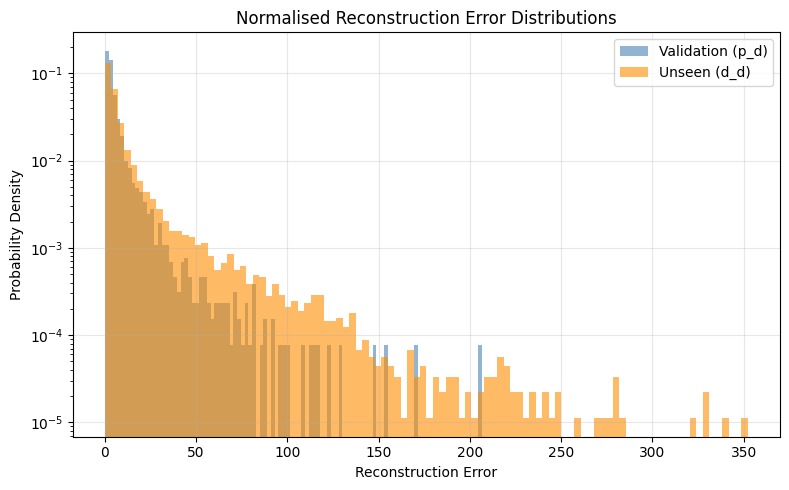

Validation mean RE: 5.904 ± 10.241
Unseen (d_d) mean RE: 10.349 ± 20.725


In [23]:
all_RE_val = np.concatenate(fold_REs)
all_RE_d_d  = np.concatenate(fold_REs_d_d)

plt.figure(figsize=(8, 5))
plt.hist(all_RE_val, bins=100, density=True, alpha=0.6, color='steelblue', label='Validation (p_d)')
plt.hist(all_RE_d_d, bins=100, density=True, alpha=0.6, color='darkorange', label='Unseen (d_d)')
plt.xlabel("Reconstruction Error")
plt.ylabel("Probability Density")
plt.title("Normalised Reconstruction Error Distributions")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Validation mean RE: {all_RE_val.mean():.3f} ± {all_RE_val.std():.3f}")
print(f"Unseen (d_d) mean RE: {all_RE_d_d.mean():.3f} ± {all_RE_d_d.std():.3f}")

Inference device: mps
recon_all.shape: (5033, 64, 64)
latent_vectors.shape: (5033, 16)
RE_per_sample.shape: (5033,)


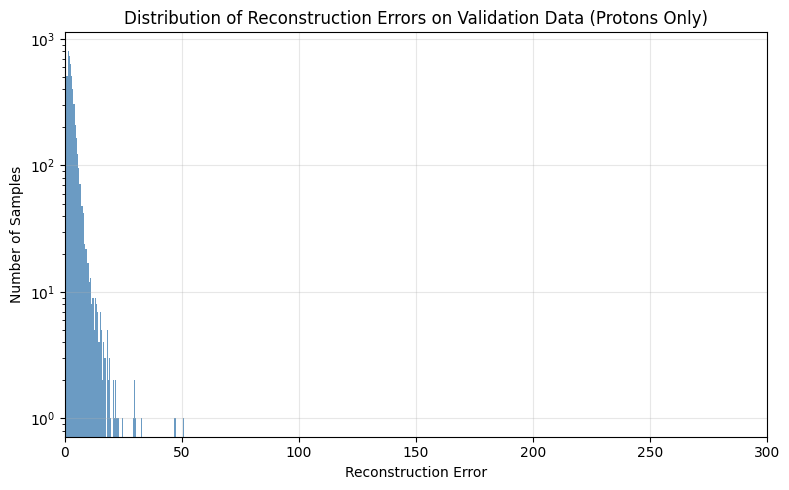

In [24]:
model.eval()

device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

model.to(device_inf)

X_np = torch.stack([train_subset[i] for i in range(len(train_subset))]).cpu().numpy()        # (N, H, W)
N, H, W = X_np.shape

batch_size = 8   
recon_all = np.empty((N, H, W), dtype=np.float32)

latent_dim = model.fc_enc.out_features
latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_np[i:j]                                 # (b, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = model(xb)                                   # (b, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all[i:j] = out_cpu

        # latent
        enc = model.encoder(xb.unsqueeze(1))              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = model.fc_enc(z_flat)                          # (b, latent)
        latent_vectors[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# per-sample MSE (RE) 
mse_per_pixel = (recon_all - X_np) ** 2
RE_per_sample = mse_per_pixel.mean(axis=(1, 2))        # (N,)

print("recon_all.shape:", recon_all.shape)
print("latent_vectors.shape:", latent_vectors.shape)
print("RE_per_sample.shape:", RE_per_sample.shape)

plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors on Validation Data (Protons Only)")
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

Inference device: mps
recon_all.shape: (1258, 64, 64)
latent_vectors.shape: (1258, 16)
RE_per_sample.shape: (1258,)


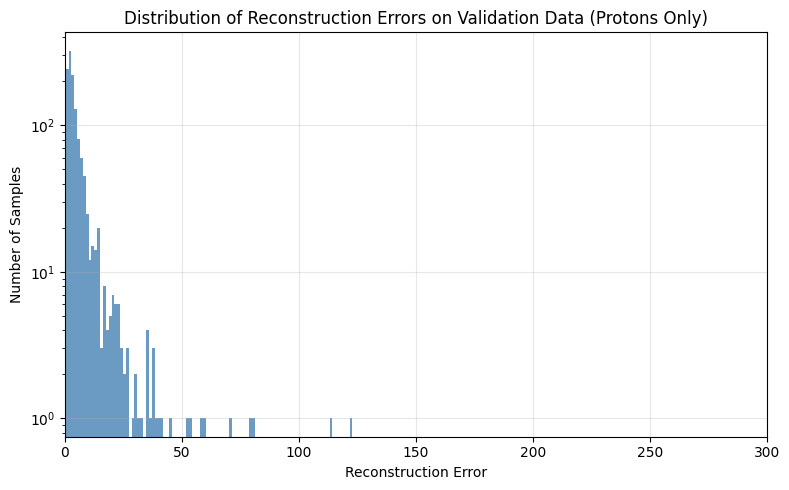

In [25]:
model.eval()

device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

model.to(device_inf)

X_nval = torch.stack([val_subset[i] for i in range(len(val_subset))]).cpu().numpy()        # (N, H, W)
N, H, W = X_nval.shape

batch_size = 8   
recon_all_val = np.empty((N, H, W), dtype=np.float32)

latent_dim = model.fc_enc.out_features
latent_vectors_val = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_nval[i:j]                                 # (b, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = model(xb)                                   # (b, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all_val[i:j] = out_cpu

        # latent
        enc = model.encoder(xb.unsqueeze(1))              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = model.fc_enc(z_flat)                          # (b, latent)
        latent_vectors_val[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# per-sample MSE (RE) 
mse_per_pixel = (recon_all_val - X_nval) ** 2
RE_per_sample_val = mse_per_pixel.mean(axis=(1, 2))        # (N,)

print("recon_all.shape:", recon_all_val.shape)
print("latent_vectors.shape:", latent_vectors_val.shape)
print("RE_per_sample.shape:", RE_per_sample_val.shape)

plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample_val, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors on Validation Data (Protons Only)")
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

recon_all_d.shape: (5115, 64, 64)
latent_vectors.shape: (5115, 16)
RE_per_sample_d.shape: (5115,)


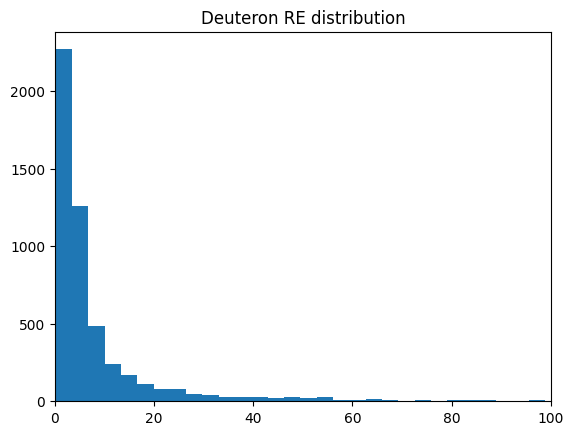

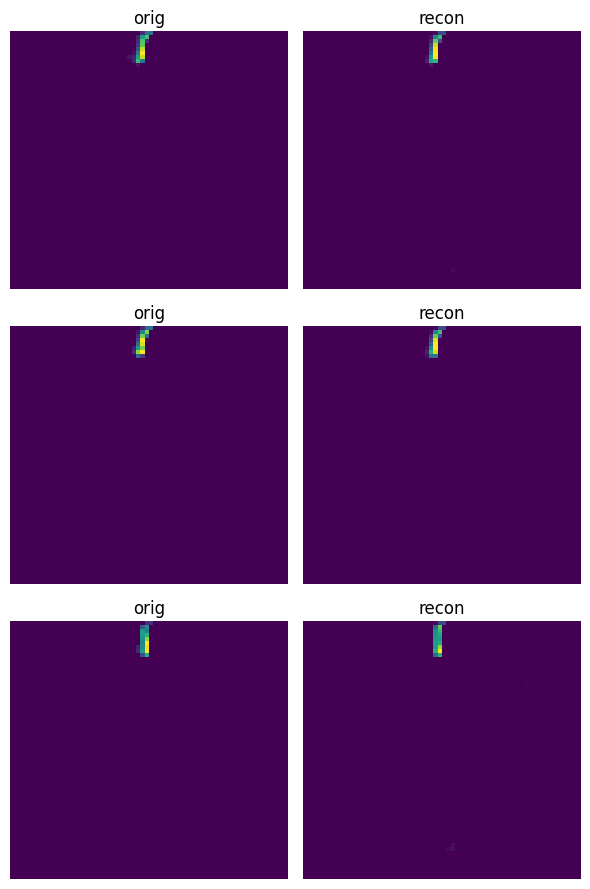

In [26]:
device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.eval()
model.to(device_inf)

Xd_np = d_d.astype(np.float32)          # (N, H, W)
N, H, W = Xd_np.shape
batch_size = 8                           # lower if OOM on MPS

recon_all_d = np.empty((N, H, W), dtype=np.float32)
latent_dim = model.fc_enc.out_features
latent_vectors_d = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb = torch.tensor(Xd_np[i:j], dtype=torch.float32).to(device_inf)  # (b,H,W)

        out = model(xb)                         # (b,H,W)
        recon_all_d[i:j] = out.cpu().numpy()

        enc = model.encoder(xb.unsqueeze(1))    # (b,C,h_enc,w_enc)
        z_flat = enc.flatten(1)                 # (b,flat_size)
        z = model.fc_enc(z_flat)                # (b,latent)
        latent_vectors_d[i:j] = z.cpu().numpy()

        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

RE_per_sample_d = ((recon_all_d - Xd_np) ** 2).mean(axis=(1, 2))

print("recon_all_d.shape:", recon_all_d.shape)
print("latent_vectors.shape:", latent_vectors_d.shape)
print("RE_per_sample_d.shape:", RE_per_sample_d.shape)

plt.figure()
plt.hist(RE_per_sample_d, bins=100)
plt.xlim(0, 100)
plt.title("Deuteron RE distribution")
plt.show()

k = min(3, N)
fig, axs = plt.subplots(k, 2, figsize=(6, 3*k))
for ii in range(k):
    axs[ii,0].imshow(Xd_np[ii], cmap='viridis', aspect='auto'); axs[ii,0].set_title("orig"); axs[ii,0].axis('off')
    axs[ii,1].imshow(recon_all_d[ii], cmap='viridis', aspect='auto'); axs[ii,1].set_title("recon"); axs[ii,1].axis('off')
plt.tight_layout()
plt.show()

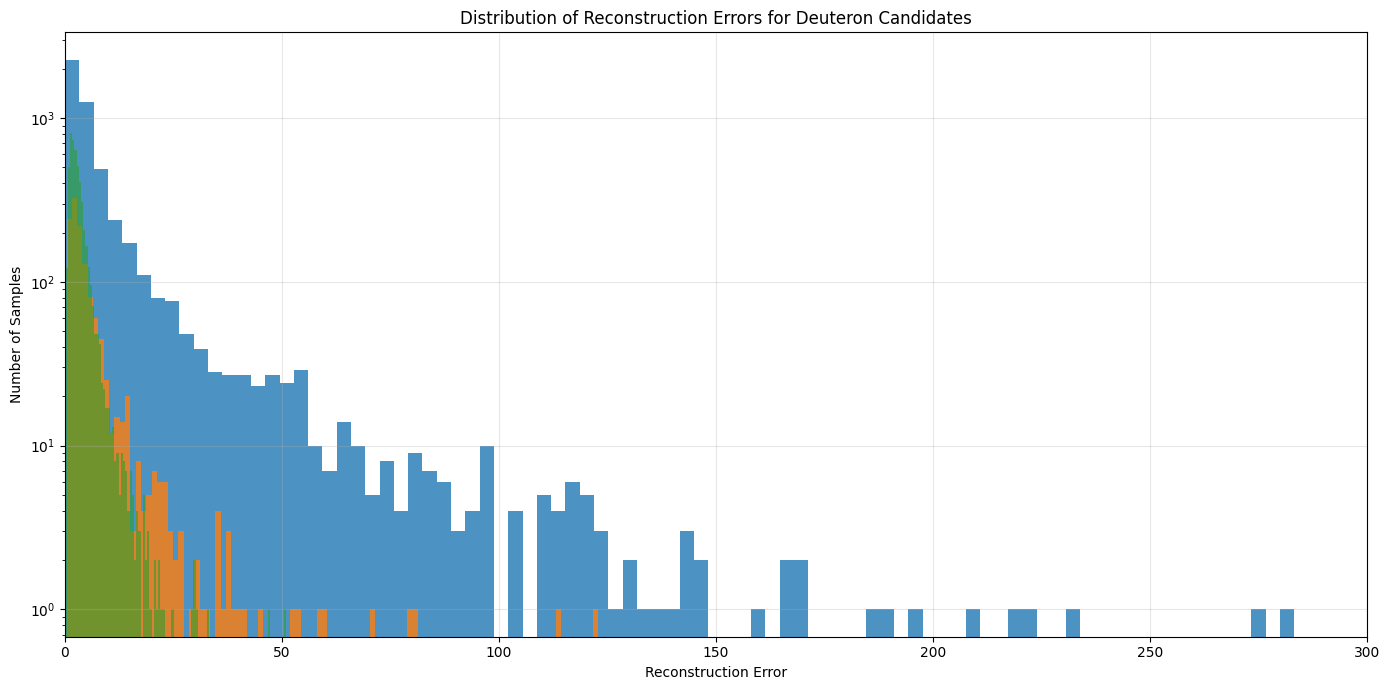

In [34]:
plt.figure(figsize=(14, 7))

plt.hist(RE_per_sample_d, bins=100, alpha=0.8)
plt.hist(RE_per_sample_val, bins=100, alpha=0.8)
plt.hist(RE_per_sample, bins=100, alpha=0.6)

plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors for Deuteron Candidates")
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

Found 4538 samples


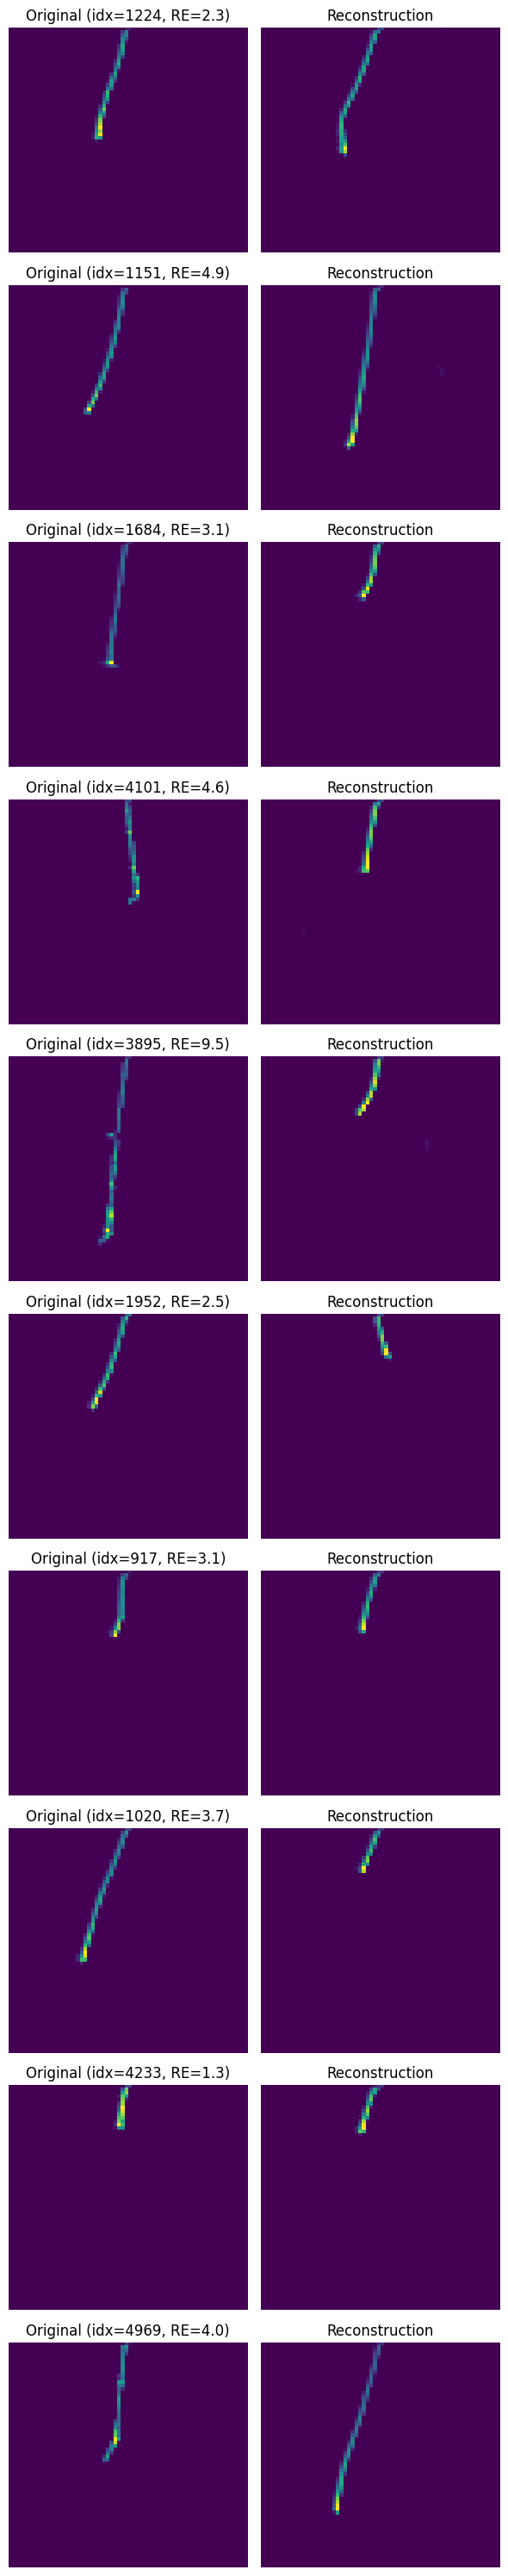

In [35]:
high_re_idx = np.where((RE_per_sample_d > 0) & (RE_per_sample_d < 20))[0]
print(f"Found {len(high_re_idx)} samples")

k = min(10, len(high_re_idx))
if k == 0:
    print("No samples with RE > 200 found.")
else:
    selected = np.random.choice(high_re_idx, size=k, replace=False)

    fig, axs = plt.subplots(k, 2, figsize=(6, 3*k))
    for ii in range(k):
        idx = selected[ii]
        axs[ii, 0].imshow(Xd_np[idx], cmap='viridis', aspect='auto')
        axs[ii, 0].set_title(f"Original (idx={idx}, RE={RE_per_sample_d[idx]:.1f})")
        axs[ii, 0].axis('off')

        axs[ii, 1].imshow(recon_all[idx], cmap='viridis', aspect='auto')
        axs[ii, 1].set_title("Reconstruction")
        axs[ii, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [36]:
x = deuterons['maxdiff'].values

deuterons.columns

Index(['event_idx', 'run', 'subrun', 'event', 'file_path', 'event_index',
       'particle_type', 'plane', 'cluster_idx', 'area', 'max_intensity',
       'min_intensity', 'mean_intensity', 'total_intensity', 'centroid_x',
       'centroid_y', 'bbox_min_row', 'bbox_min_col', 'bbox_max_row',
       'bbox_max_col', 'width', 'height', 'aspect_ratio', 'compactness',
       'image_intensity', 'matrix_transformed', 'column_maxes', 'normalised',
       'adcdiff', 'maxdiff', 'energy', 'rr', 'e_diff', 'rr_diff', 'p', 'm',
       'beamline_mass'],
      dtype='object')

Text(0.5, 0, 'Mass')

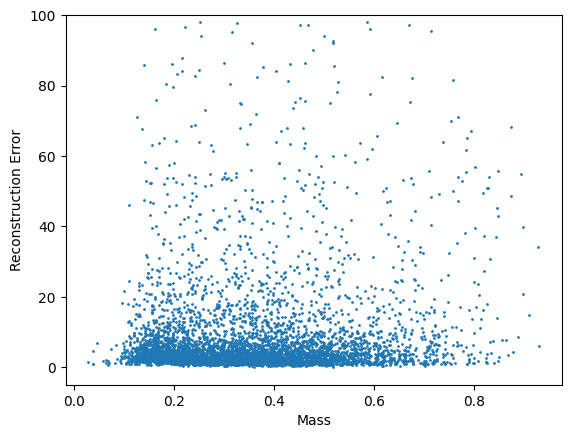

In [37]:
plt.scatter(x, RE_per_sample_d, s=1)
plt.ylim(-5, 100)
plt.ylabel('Reconstruction Error')
plt.xlabel('Mass')

In [38]:
latent_vectors_d.shape, RE_per_sample_d.shape, recon_all_d.shape

((5115, 16), (5115,), (5115, 64, 64))

In [39]:
latent_vectors.shape, RE_per_sample.shape, recon_all.shape

((5033, 16), (5033,), (5033, 64, 64))

In [40]:
latent_vectors_val.shape, RE_per_sample_val.shape, recon_all_val.shape

((1258, 16), (1258,), (1258, 64, 64))

In [41]:
from sklearn.manifold import TSNE

Z_all = np.concatenate([latent_vectors, latent_vectors_d, latent_vectors_val], axis=0)
labels = np.concatenate([
    np.zeros(len(latent_vectors)),          # 0 = protons
    np.ones(len(latent_vectors_d)),         # 1 = deuterons
    np.full(len(latent_vectors_val), 2)     # 2 = validation
])

# Run t-SNE directly (16-D input is fine)
tsne = TSNE(
    n_components=2,
    perplexity=50,
    learning_rate=50,
    max_iter=2000,
    init='random',
    random_state=42
)
Z_2d = tsne.fit_transform(Z_all)

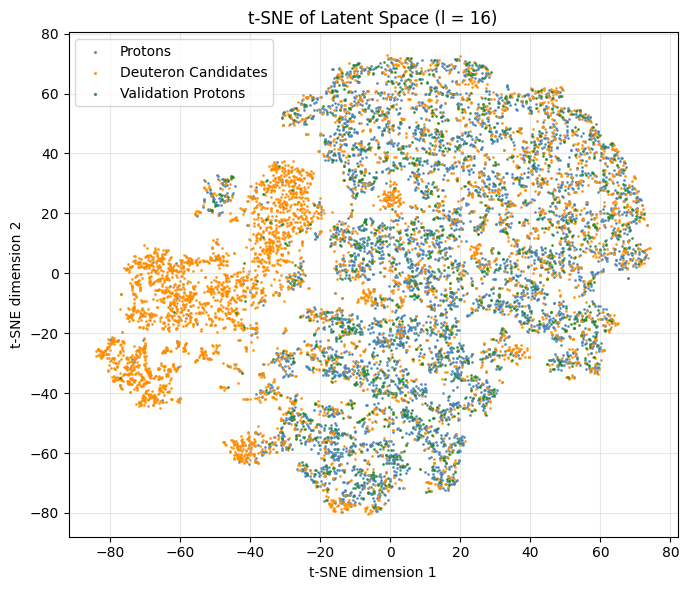

In [42]:
%matplotlib inline

# Plot with three colours
plt.figure(figsize=(7, 6))
colours = ['steelblue', 'darkorange', 'forestgreen']
labels_text = ['Protons', 'Deuteron Candidates', 'Validation Protons']

for i, (colour, label_name) in enumerate(zip(colours, labels_text)):
    plt.scatter(Z_2d[labels == i, 0],
                Z_2d[labels == i, 1],
                color=colour,
                alpha=0.8,
                s=1,
                label=label_name)

plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(markerscale=1.3)
plt.title("t-SNE of Latent Space (l = 16)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

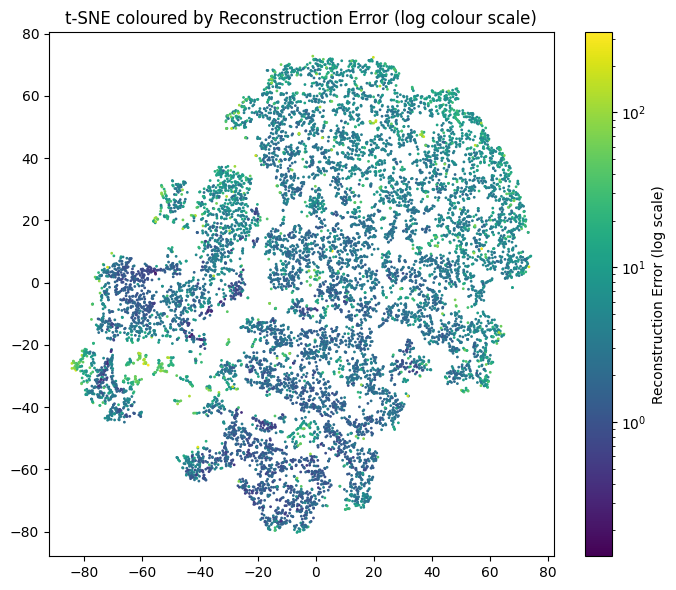

In [43]:
import matplotlib.colors as mcolors

Z_all = np.concatenate([latent_vectors, latent_vectors_d, latent_vectors_val])
RE_all = np.concatenate([RE_per_sample, RE_per_sample_d, RE_per_sample_val])

plt.figure(figsize=(7,6))
sc = plt.scatter(Z_2d[:, 0], Z_2d[:, 1],
                 c=RE_all,
                 cmap='viridis',
                 norm=mcolors.LogNorm(vmin=RE_all.min()+1e-8, vmax=RE_all.max()),
                 s=1)
plt.colorbar(sc, label='Reconstruction Error (log scale)')
plt.title("t-SNE coloured by Reconstruction Error (log colour scale)")
plt.tight_layout()
plt.show()

# low error regions and high error regions in deuteron candidates?
# overlap with proton latent vectors?
# separation with proton latent vectors

In [44]:
import umap
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
Z_umap = reducer.fit_transform(Z_all)

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


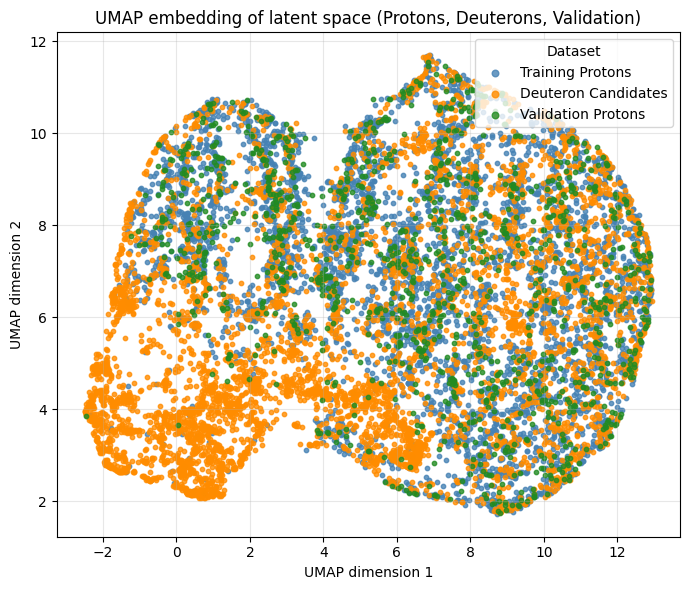

In [45]:
# labels: 0=Protons, 1=Deuterons, 2=Validation
palette = ['steelblue', 'darkorange', 'forestgreen']  # order matches labels

plt.figure(figsize=(7,6))
for i, name in enumerate(['Training Protons', 'Deuteron Candidates', 'Validation Protons']):
    m = (labels == i)
    plt.scatter(Z_umap[m, 0], Z_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)

plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.title("UMAP embedding of latent space (Protons, Deuterons, Validation)")
plt.legend(title="Dataset", markerscale=1.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


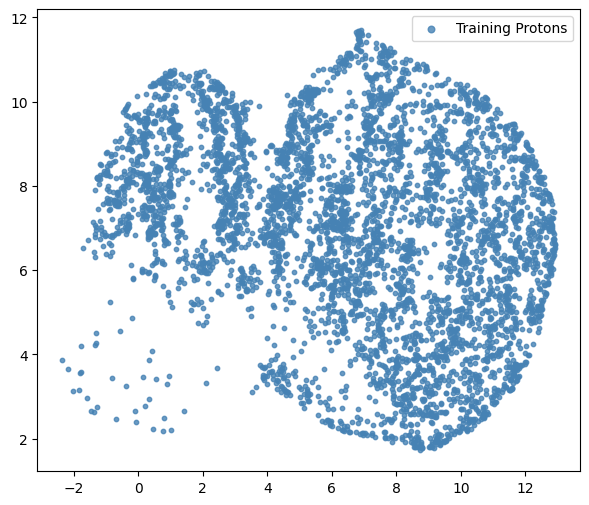

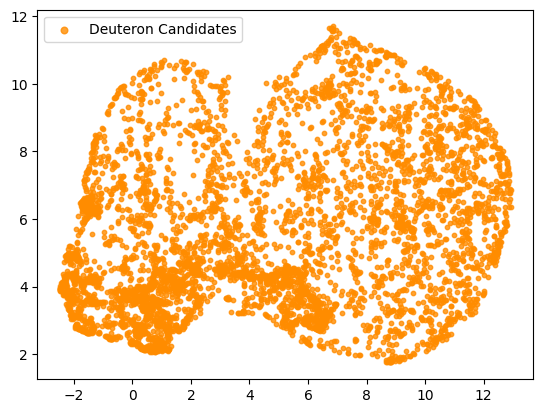

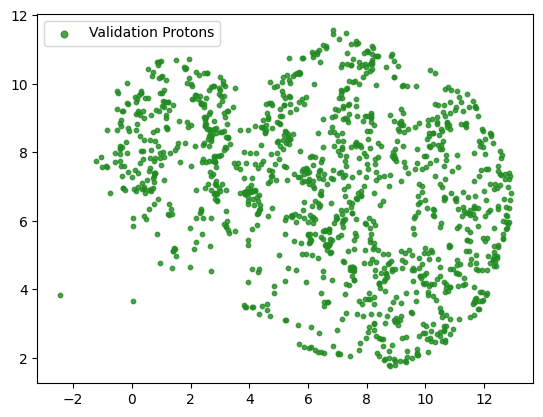

In [46]:
# labels: 0=Protons, 1=Deuterons, 2=Validation
palette = ['steelblue', 'darkorange', 'forestgreen']  # order matches labels

plt.figure(figsize=(7,6))
for i, name in enumerate(['Training Protons', 'Deuteron Candidates', 'Validation Protons']):
    m = (labels == i)
    plt.scatter(Z_umap[m, 0], Z_umap[m, 1],
                color=palette[i], s=10, alpha=0.8, label=name)
    plt.legend(markerscale=1.5)
    plt.show()

# plt.xlabel("UMAP dimension 1")
# plt.ylabel("UMAP dimension 2")
# plt.title("UMAP embedding of latent space (Protons, Deuterons, Validation)")
# plt.legend(title="Dataset", markerscale=1.5)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()


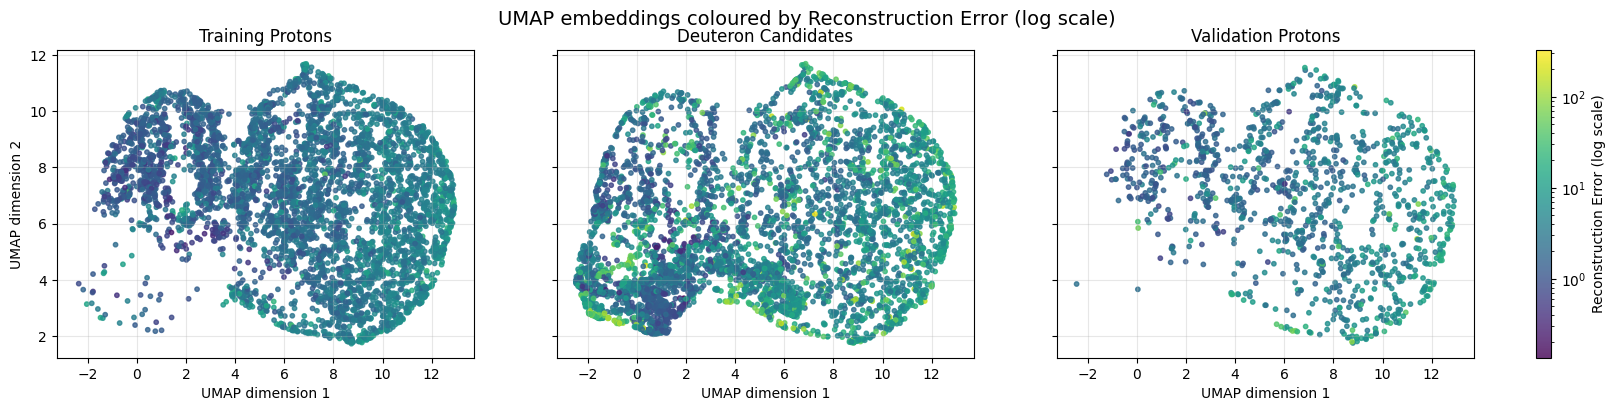

In [47]:
palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

norm = mcolors.LogNorm(vmin=RE_all.min() + 1e-8, vmax=RE_all.max())
cmap = plt.cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(20, 4), sharex=True, sharey=True)

for i, ax in enumerate(axes):
    m = (labels == i)
    sc = ax.scatter(
        Z_umap[m, 0],
        Z_umap[m, 1],
        c=RE_all[m],
        cmap=cmap,
        norm=norm,
        s=10,
        alpha=0.8
    )
    ax.set_title(names[i], fontsize=12)
    ax.set_xlabel("UMAP dimension 1")
    if i == 0:
        ax.set_ylabel("UMAP dimension 2")
    ax.grid(True, alpha=0.3)

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('Reconstruction Error (log scale)')

fig.suptitle("UMAP embeddings coloured by Reconstruction Error (log scale)", fontsize=14)
plt.show()


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


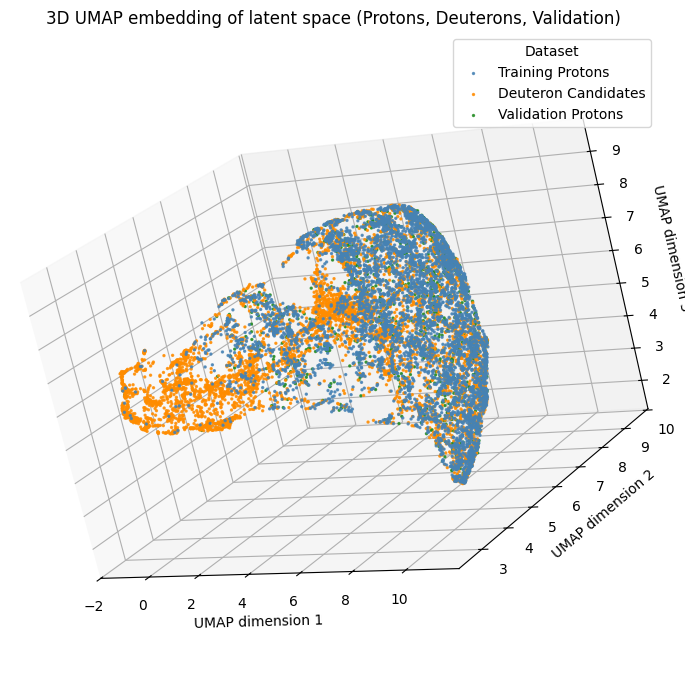

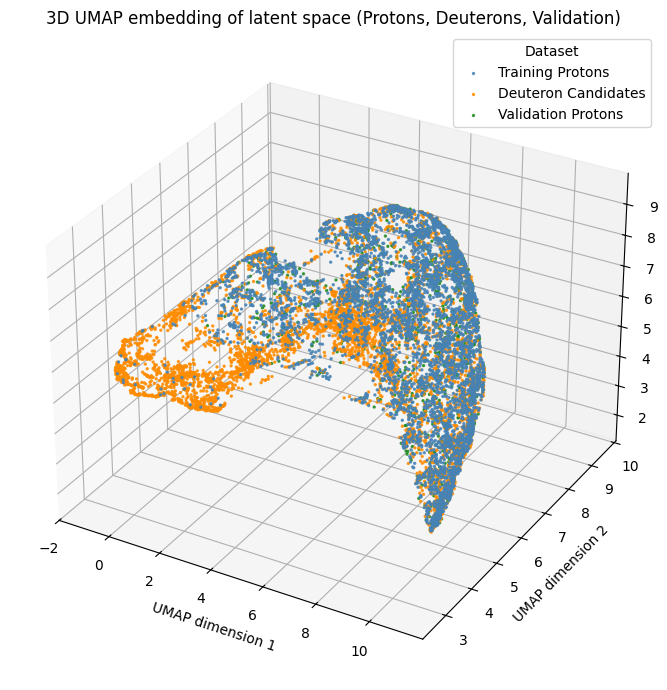

In [49]:
%matplotlib inline

from mpl_toolkits.mplot3d import Axes3D

umap_3d = umap.UMAP(n_components=3, random_state=42)
embedding = umap_3d.fit_transform(Z_all)

palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for i, name in enumerate(names):
    mask = (labels == i)
    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        embedding[mask, 2],
        color=palette[i],
        s=2,
        alpha=0.8,
        label=name
    )

ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.set_zlabel("UMAP dimension 3")
ax.set_title("3D UMAP embedding of latent space (Protons, Deuterons, Validation)")
ax.legend(title="Dataset", loc="upper right")

# ax.view_init(elev=45, azim=45)         # azim 0 along x, 90 along y

plt.tight_layout()
plt.show()


/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


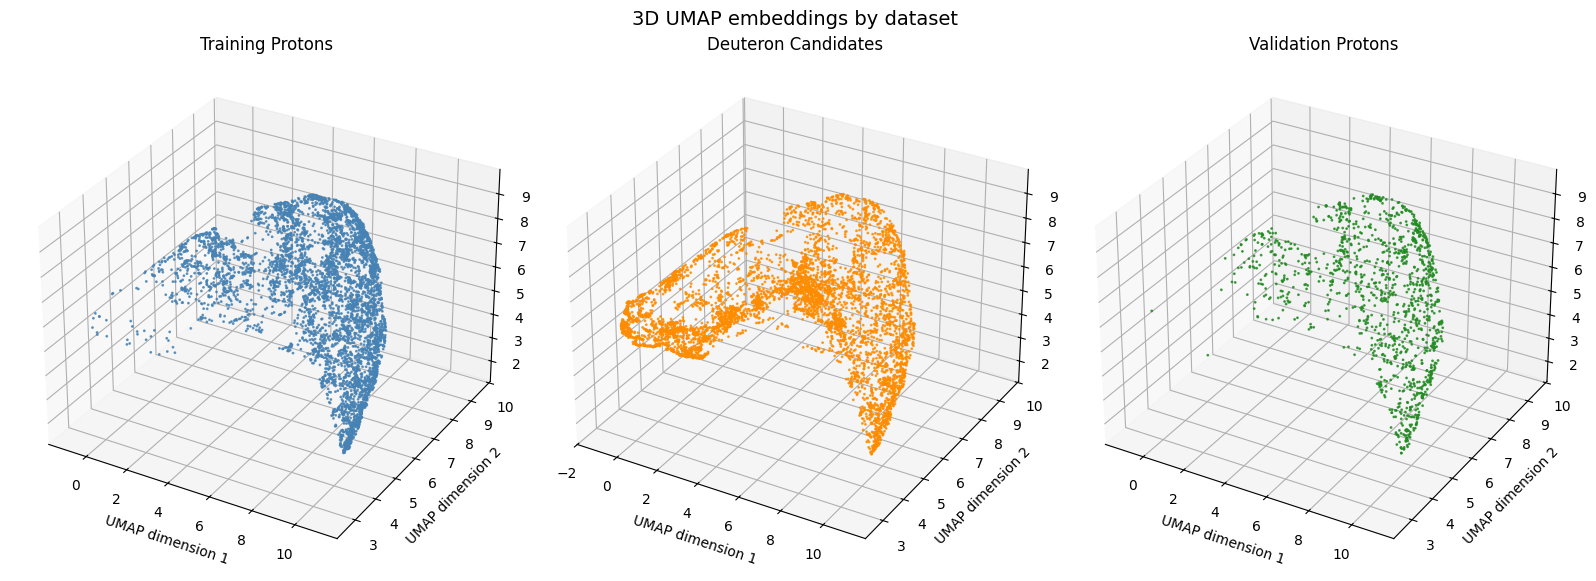

In [50]:
umap_3d = umap.UMAP(n_components=3, random_state=42)
embedding = umap_3d.fit_transform(Z_all)

palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

fig = plt.figure(figsize=(16, 6))

for i, name in enumerate(names):
    mask = (labels == i)
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        embedding[mask, 2],
        color=palette[i],
        s=1,
        alpha=0.8
    )
    ax.set_title(name)
    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")
    ax.set_zlabel("UMAP dimension 3")
    # ax.view_init(elev=25, azim=45)  

fig.suptitle("3D UMAP embeddings by dataset", fontsize=14)
plt.tight_layout()
plt.show()


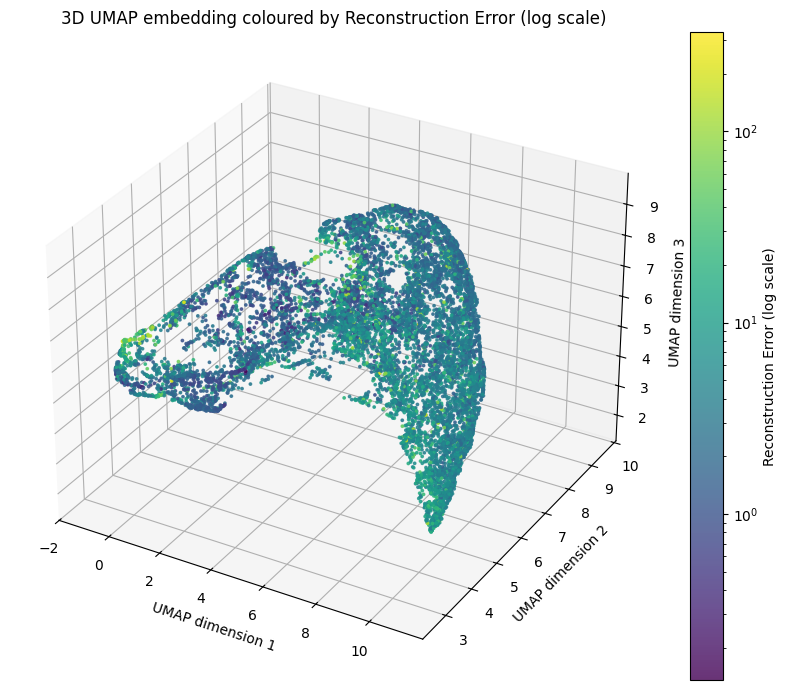

In [51]:
%matplotlib inline

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot coloured by reconstruction error
sc = ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    embedding[:, 2],
    c=RE_all,
    cmap='viridis',
    norm=mcolors.LogNorm(vmin=RE_all.min() + 1e-8, vmax=RE_all.max()),
    s=3,
    alpha=0.8
)

# Axis labels and title
ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.set_zlabel("UMAP dimension 3")
ax.set_title("3D UMAP embedding coloured by Reconstruction Error (log scale)")

# Colour bar
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Reconstruction Error (log scale)')

plt.tight_layout()
plt.show()


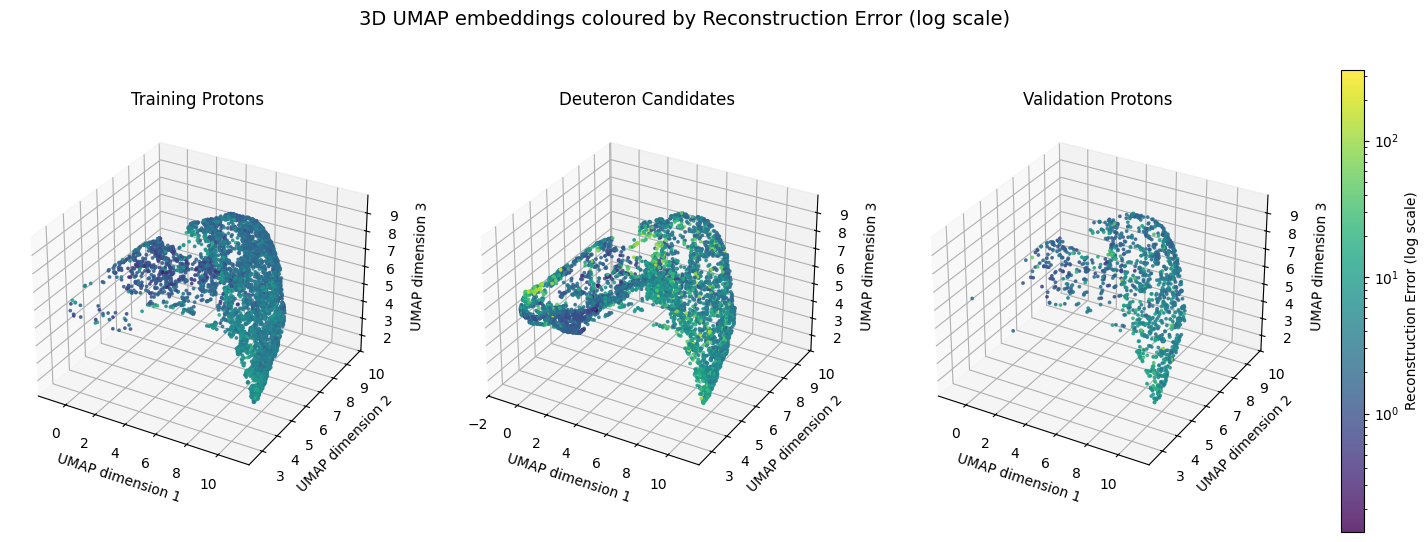

In [52]:
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Assume: embedding (3D UMAP), RE_all (reconstruction errors), labels (0,1,2)
palette = ['steelblue', 'darkorange', 'forestgreen']
names = ['Training Protons', 'Deuteron Candidates', 'Validation Protons']

# Shared normalisation and colormap for all plots
norm = mcolors.LogNorm(vmin=RE_all.min() + 1e-8, vmax=RE_all.max())
cmap = plt.cm.viridis

fig = plt.figure(figsize=(18, 6))

for i, name in enumerate(names):
    mask = (labels == i)
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')

    sc = ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        embedding[mask, 2],
        c=RE_all[mask],
        cmap=cmap,
        norm=norm,
        s=3,
        alpha=0.8
    )

    ax.set_title(name, fontsize=12)
    ax.set_xlabel("UMAP dimension 1")
    ax.set_ylabel("UMAP dimension 2")
    ax.set_zlabel("UMAP dimension 3")
    # ax.view_init(elev=25, azim=45)  # consistent 3D orientation

# Shared colour bar for all subplots
cbar = fig.colorbar(sc, ax=fig.get_axes(), fraction=0.046, pad=0.04)
cbar.set_label('Reconstruction Error (log scale)')

fig.suptitle("3D UMAP embeddings coloured by Reconstruction Error (log scale)", fontsize=14)
plt.show()


Deuteron subset shape: (5115, 3)
DBSCAN found 2 clusters (and 4940 noise points)


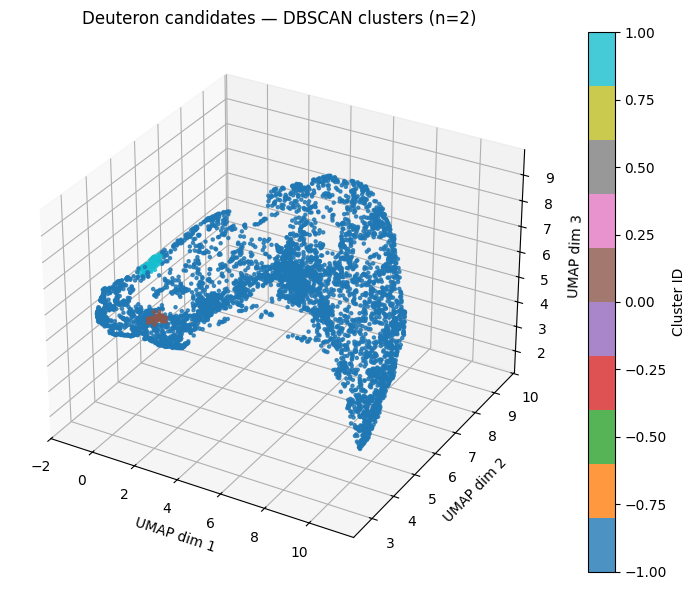

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-pac

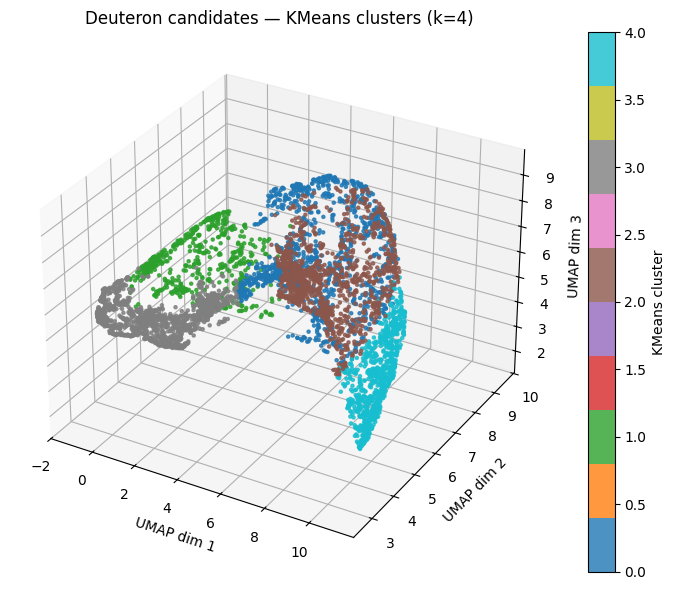

In [53]:
from sklearn.cluster import DBSCAN, KMeans


# Select only deuteron candidates
mask = (labels == 1)
Z_d = Z_all[mask]          # latent vectors
E_d = embedding[mask]      # 3D UMAP coordinates

print(f"Deuteron subset shape: {E_d.shape}")

# -------------------------------------------------
# Option 1: Density-based clustering (DBSCAN)
# -------------------------------------------------
db = DBSCAN(eps=0.3, min_samples=50).fit(E_d)
labels_db = db.labels_

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
print(f"DBSCAN found {n_clusters} clusters (and {np.sum(labels_db == -1)} noise points)")

# Visualise
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(E_d[:, 0], E_d[:, 1], E_d[:, 2],
                c=labels_db, cmap='tab10', s=5, alpha=0.8)
plt.colorbar(sc, ax=ax, label='Cluster ID')
ax.set_title(f"Deuteron candidates — DBSCAN clusters (n={n_clusters})")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.set_zlabel("UMAP dim 3")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Option 2: Centroid-based clustering (KMeans)
# -------------------------------------------------
kmeans = KMeans(n_clusters=5, random_state=42)
labels_km = kmeans.fit_predict(E_d)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(E_d[:, 0], E_d[:, 1], E_d[:, 2],
                c=labels_km, cmap='tab10', s=5, alpha=0.8)
plt.colorbar(sc, ax=ax, label='KMeans cluster')
ax.set_title("Deuteron candidates — KMeans clusters (k=4)")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.set_zlabel("UMAP dim 3")
plt.tight_layout()
plt.show()


Cluster 2: 1180 samples
Filtered: 1180 samples with RE in range


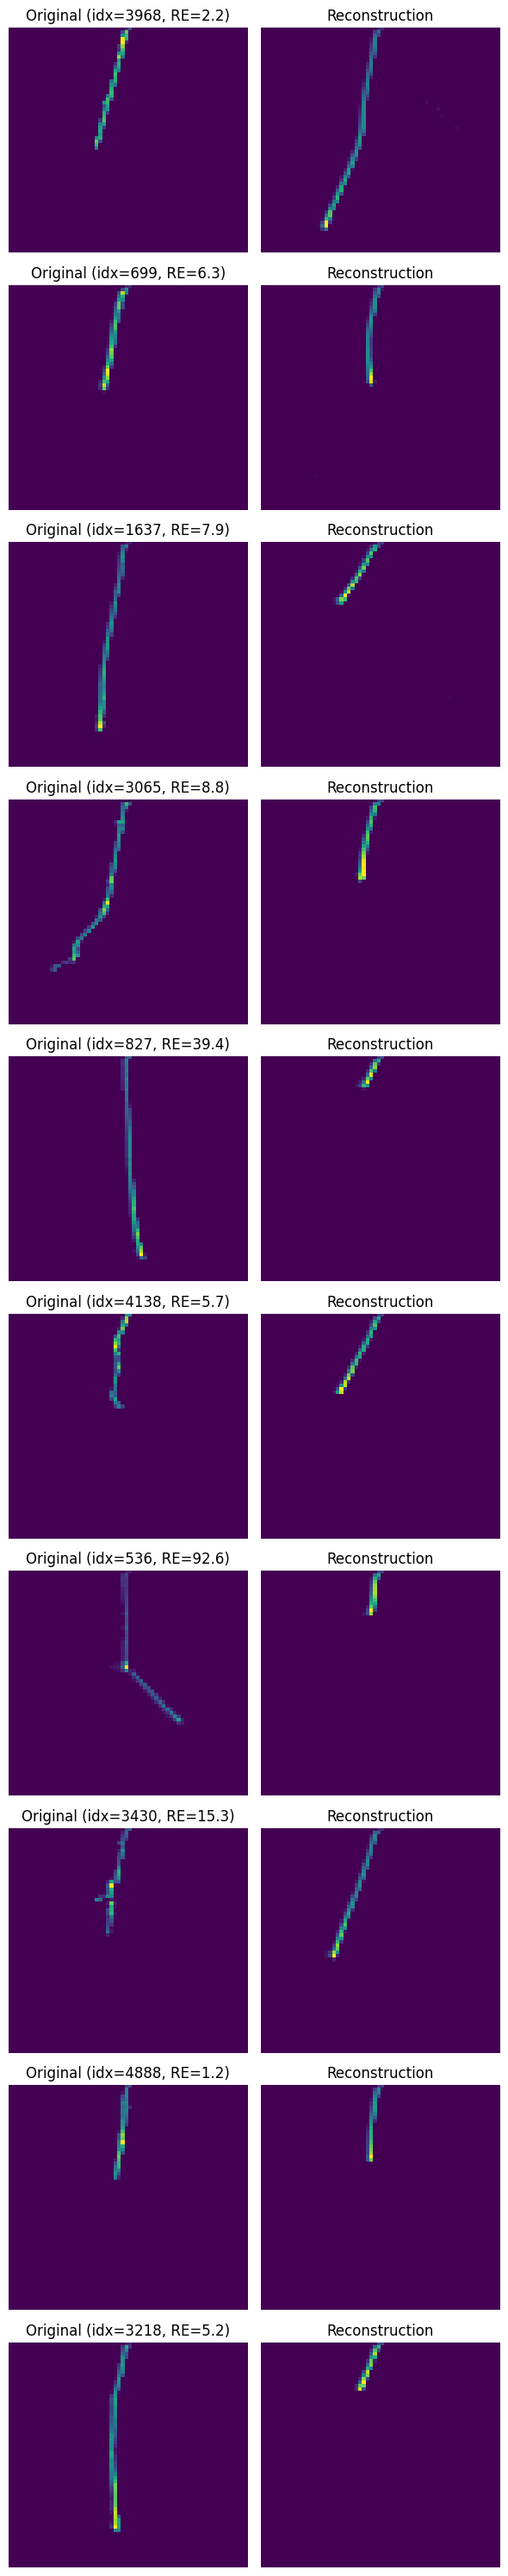

In [63]:
cluster_id = 2

cluster_mask = (labels_km == cluster_id)
cluster_indices = np.where(cluster_mask)[0]
print(f"Cluster {cluster_id}: {len(cluster_indices)} samples")

filtered_idx = cluster_indices[(RE_per_sample_d[cluster_indices] > 0) &
                               (RE_per_sample_d[cluster_indices] < 2000)]

print(f"Filtered: {len(filtered_idx)} samples with RE in range")

k = min(10, len(filtered_idx))
if k == 0:
    print(f"No samples found in cluster {cluster_id} with RE in range.")
else:
    selected = np.random.choice(filtered_idx, size=k, replace=False)

    fig, axs = plt.subplots(k, 2, figsize=(6, 3*k))
    for ii in range(k):
        idx = selected[ii]
        axs[ii, 0].imshow(Xd_np[idx], cmap='viridis', aspect='auto')
        axs[ii, 0].set_title(f"Original (idx={idx}, RE={RE_per_sample_d[idx]:.1f})")
        axs[ii, 0].axis('off')

        axs[ii, 1].imshow(recon_all[idx], cmap='viridis', aspect='auto')
        axs[ii, 1].set_title("Reconstruction")
        axs[ii, 1].axis('off')

    plt.tight_layout()
    plt.show()


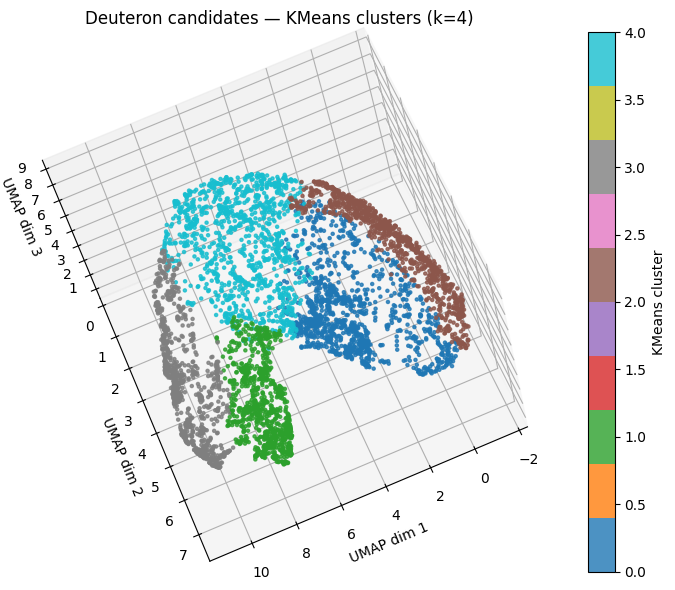

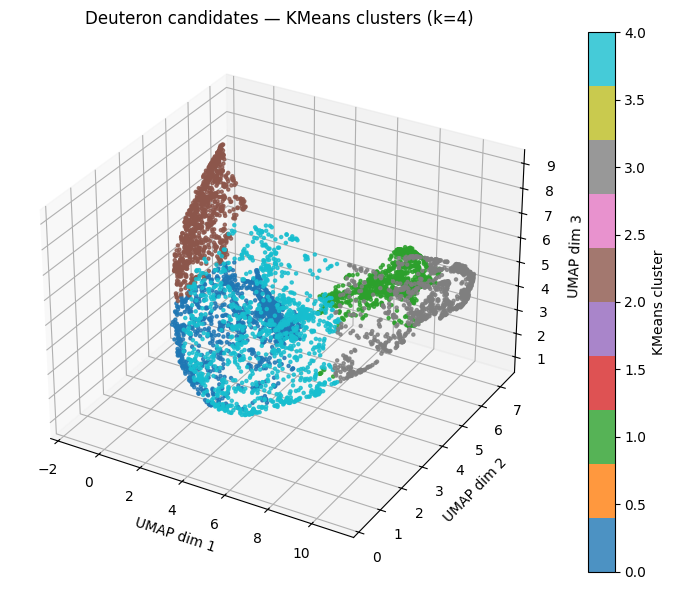

In [292]:
%matplotlib inline

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(E_d[:, 0], E_d[:, 1], E_d[:, 2],
                c=labels_km, cmap='tab10', s=5, alpha=0.8)
plt.colorbar(sc, ax=ax, label='KMeans cluster')
ax.set_title("Deuteron candidates — KMeans clusters (k=4)")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.set_zlabel("UMAP dim 3")
plt.tight_layout()
plt.show()

DBSCAN found 12 clusters (and 10627 noise points)


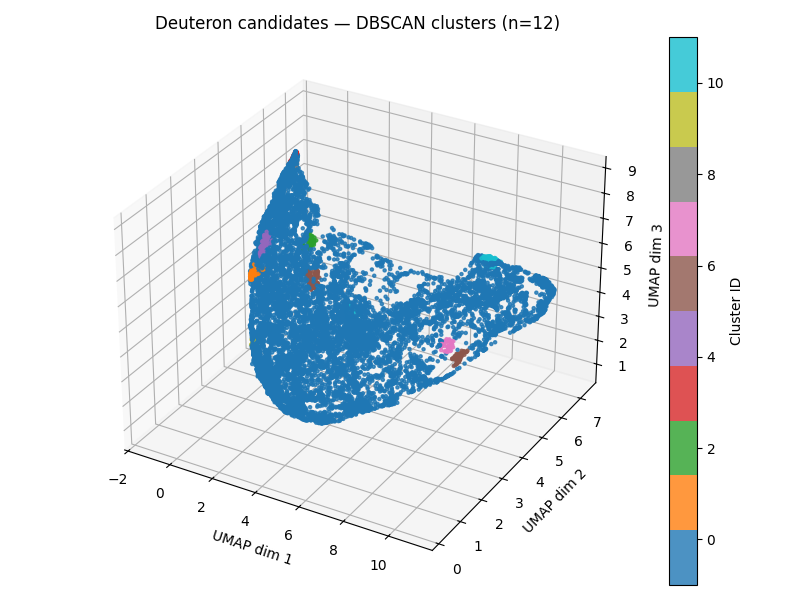

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-pac

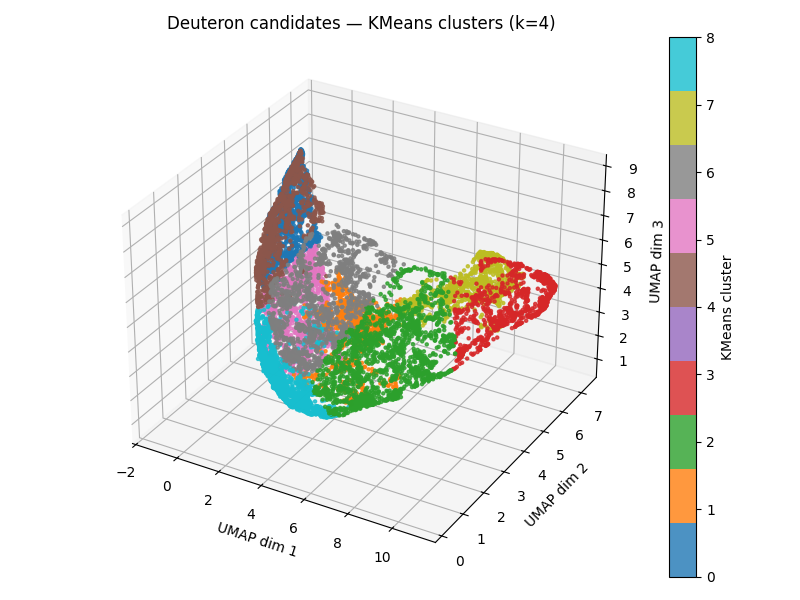

In [309]:
from sklearn.cluster import DBSCAN, KMeans


# Select only deuteron candidates
Z_d = Z_all       # latent vectors
E_d = embedding     # 3D UMAP coordinates

# -------------------------------------------------
# Option 1: Density-based clustering (DBSCAN)
# -------------------------------------------------
db = DBSCAN(eps=0.3, min_samples=50).fit(E_d)
labels_db = db.labels_

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
print(f"DBSCAN found {n_clusters} clusters (and {np.sum(labels_db == -1)} noise points)")

# Visualise
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(E_d[:, 0], E_d[:, 1], E_d[:, 2],
                c=labels_db, cmap='tab10', s=5, alpha=0.8)
plt.colorbar(sc, ax=ax, label='Cluster ID')
ax.set_title(f"Deuteron candidates — DBSCAN clusters (n={n_clusters})")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.set_zlabel("UMAP dim 3")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Option 2: Centroid-based clustering (KMeans)
# -------------------------------------------------
kmeans = KMeans(n_clusters=9, random_state=42)
labels_km = kmeans.fit_predict(E_d)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(E_d[:, 0], E_d[:, 1], E_d[:, 2],
                c=labels_km, cmap='tab10', s=5, alpha=0.8)
plt.colorbar(sc, ax=ax, label='KMeans cluster')
ax.set_title("Deuteron candidates — KMeans clusters (k=4)")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.set_zlabel("UMAP dim 3")
plt.tight_layout()
plt.show()


In [65]:
latent_vectors.shape, latent_vectors_val.shape, latent_vectors_d.shape

((5033, 16), (1258, 16), (5115, 16))

In [67]:
latent = np.concatenate([latent_vectors, latent_vectors_val])

Deuteron subset shape: (5115, 3)
DBSCAN found 2 clusters (and 4940 noise points)


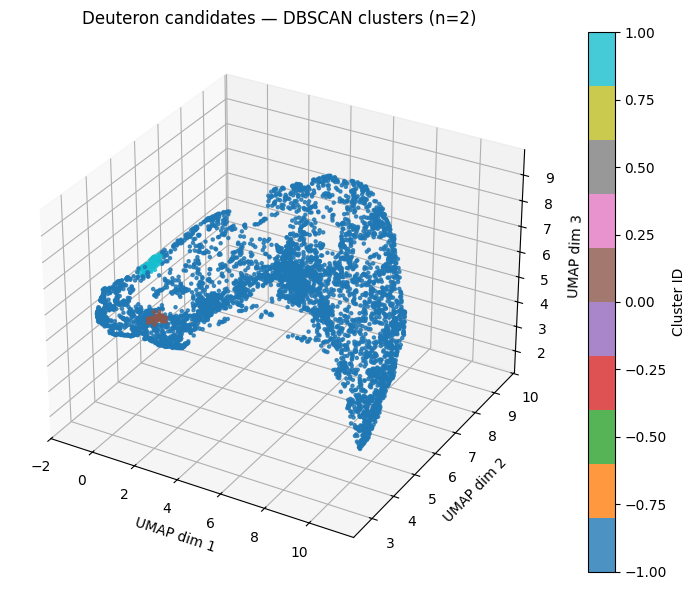

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-pac

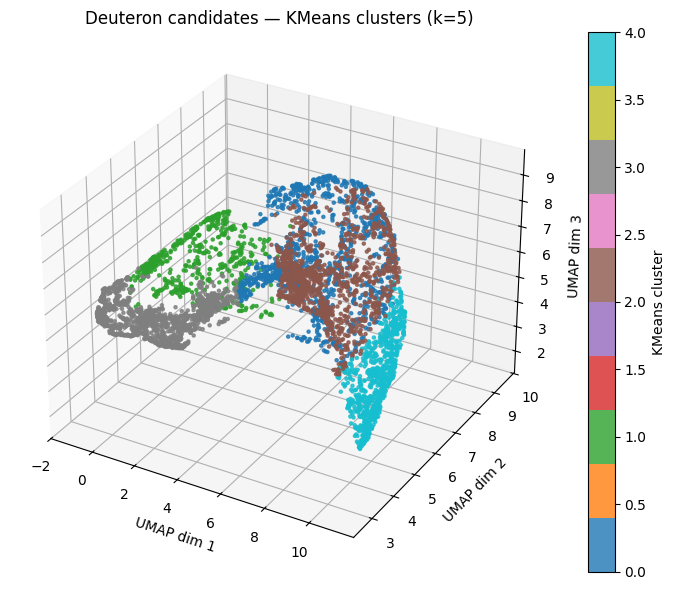

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-pac

GMM fitted with 2 components.
Average cluster assignment confidence: 0.981


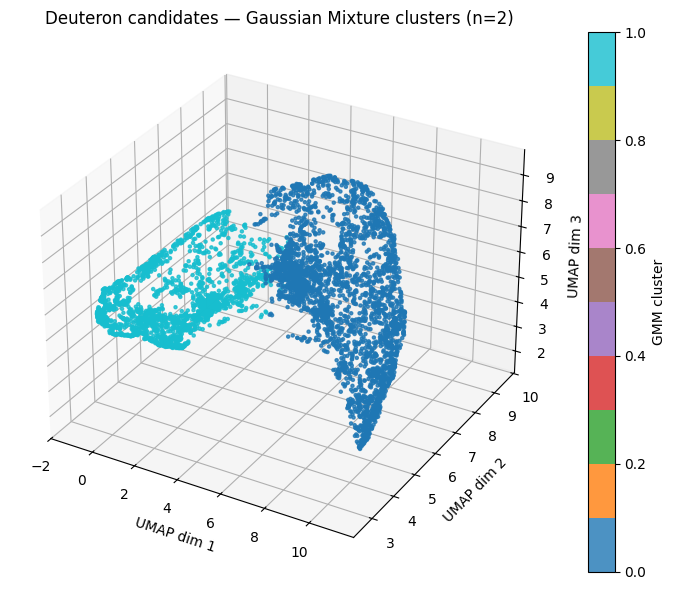

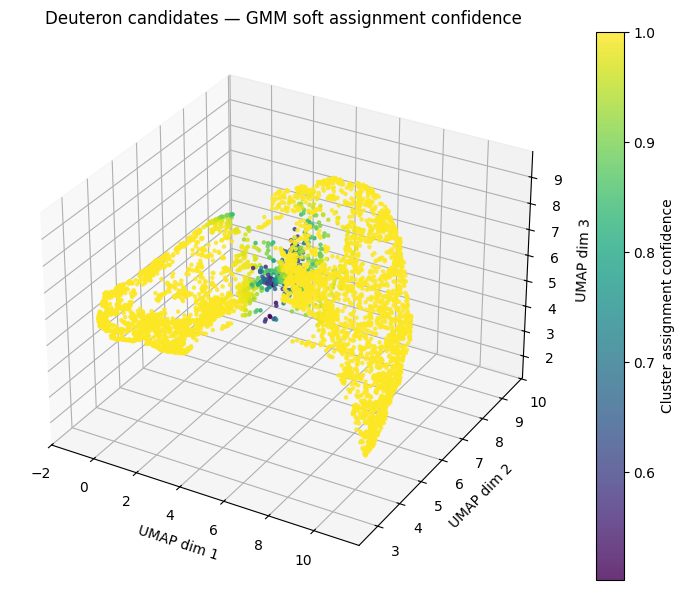

In [ ]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Select only deuteron candidates
# -------------------------------------------------
mask = (labels == 1)
Z_d = Z_all[mask]          # latent vectors
E_d = embedding[mask]      # 3D UMAP coordinates

print(f"Deuteron subset shape: {E_d.shape}")

# -------------------------------------------------
# Option 1: Density-based clustering (DBSCAN)
# -------------------------------------------------
db = DBSCAN(eps=0.3, min_samples=50).fit(E_d)
labels_db = db.labels_

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
print(f"DBSCAN found {n_clusters} clusters (and {np.sum(labels_db == -1)} noise points)")

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(E_d[:, 0], E_d[:, 1], E_d[:, 2],
                c=labels_db, cmap='tab10', s=5, alpha=0.8)
plt.colorbar(sc, ax=ax, label='Cluster ID')
ax.set_title(f"Deuteron candidates — DBSCAN clusters (n={n_clusters})")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.set_zlabel("UMAP dim 3")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Option 2: Centroid-based clustering (KMeans)
# -------------------------------------------------
kmeans = KMeans(n_clusters=5, random_state=42)
labels_km = kmeans.fit_predict(E_d)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(E_d[:, 0], E_d[:, 1], E_d[:, 2],
                c=labels_km, cmap='tab10', s=5, alpha=0.8)
plt.colorbar(sc, ax=ax, label='KMeans cluster')
ax.set_title("Deuteron candidates — KMeans clusters (k=5)")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.set_zlabel("UMAP dim 3")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# Option 3: Probabilistic clustering (Gaussian Mixture Model)
# -------------------------------------------------
n_components = 2
gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
labels_gmm = gmm.fit_predict(E_d)
probs_gmm = gmm.predict_proba(E_d)  # soft cluster probabilities

print(f"GMM fitted with {n_components} components.")
print(f"Average cluster assignment confidence: {np.mean(np.max(probs_gmm, axis=1)):.3f}")

# Visualise GMM clusters (by most likely component)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(E_d[:, 0], E_d[:, 1], E_d[:, 2],
                c=labels_gmm, cmap='tab10', s=5, alpha=0.8)
plt.colorbar(sc, ax=ax, label='GMM cluster')
ax.set_title(f"Deuteron candidates — Gaussian Mixture clusters (n={n_components})")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.set_zlabel("UMAP dim 3")
plt.tight_layout()
plt.show()

# Optional: Visualise uncertainty (confidence in assignment)
confidence = np.max(probs_gmm, axis=1)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(E_d[:, 0], E_d[:, 1], E_d[:, 2],
                c=confidence, cmap='viridis', s=5, alpha=0.8)
plt.colorbar(sc, ax=ax, label='Cluster assignment confidence')
ax.set_title("Deuteron candidates — GMM soft assignment confidence")
ax.set_xlabel("UMAP dim 1")
ax.set_ylabel("UMAP dim 2")
ax.set_zlabel("UMAP dim 3")
plt.tight_layout()
plt.show()
